# UR5 Robot Kinematics: Complete Dual Quaternion Pipeline

## Full implementation of:
- **Screw Theory** — geometric joint axis representation
- **Product of Exponentials (PoE)** — forward kinematics
- **Dual Quaternions** — singularity-free pose representation
- **Analytical DQ Jacobian** — velocity and IK
- **Numerical IK** — damped least squares with joint limits
- **ScLERP** — screw-linear trajectory interpolation
- **Neural Network IK** — DQ input, joint angle output
- **Hybrid Solver** — NN warm start + numerical refinement

## Robot: Universal Robots UR5
- 6 Revolute joints (6R)
- Reach: ~850 mm, Payload: 5 kg
- All units: **metres** and **radians**

---
**Reference:** Modern Robotics — Lynch & Park (2017)


## Cell 1 — Install and Import Dependencies

We use:
- `numpy` — all linear algebra and array operations
- `scipy` — matrix exponential via `expm` (used for verification only)
- `tensorflow` / `keras` — neural network for learned IK
- `matplotlib` — plotting errors and trajectories

We do **NOT** use the `dual_quaternions` library — we implement everything
from scratch so the maths is fully transparent and correct.


In [1]:
# Install required packages
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'numpy', 'scipy', 'tensorflow', 'matplotlib', 'tqdm', '-q'])



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


0

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
from scipy.linalg import expm
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=6, suppress=True)
print(f'NumPy  : {np.__version__}')
print(f'TF     : {tf.__version__}')
print('All imports successful.')

I0000 00:00:1779029751.825255    5100 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779029751.831165    5100 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779029763.454516    5100 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779029773.840841    5100 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

NumPy  : 2.4.4
TF     : 2.21.0
All imports successful.


---
## PART 1 — UR5 GEOMETRY: DH PARAMETERS

The UR5 uses **Modified DH (Craig convention)**.
Each row describes the transform from frame i-1 to frame i:

| Joint | a (m)     | α (rad)  | d (m)    | θ offset |
|-------|-----------|----------|----------|----------|
| 1     | 0         | 0        | 0.1273   | 0        |
| 2     | 0         | -π/2     | 0        | 0        |
| 3     | -0.4250   | 0        | 0        | 0        |
| 4     | -0.3922   | 0        | 0.1091   | 0        |
| 5     | 0         | +π/2     | 0.0946   | 0        |
| 6     | 0         | -π/2     | 0.0823   | 0        |

Where:
- **a** = link length along x-axis
- **α** = link twist about x-axis  
- **d** = link offset along z-axis
- **θ** = joint angle about z-axis (our variable)


In [3]:
# ============================================================
# UR5 DH Parameters (Modified DH / Craig Convention)
# All distances in metres, angles in radians
# ============================================================

# Link lengths along x-axis (a_i-1)
DH_a     = np.array([0.0,      0.0,      -0.42500, -0.39225,  0.0,      0.0    ])

# Link twists about x-axis (alpha_i-1) in radians
DH_alpha = np.array([0.0,     -np.pi/2,   0.0,      0.0,      np.pi/2, -np.pi/2])

# Link offsets along z-axis (d_i) in metres
DH_d     = np.array([0.1273,   0.0,        0.0,      0.10915,  0.09465,  0.0823 ])

# Zero-configuration joint angles (theta offsets)
DH_theta = np.zeros(6)

print('UR5 DH Parameters:')
print(f'{"Joint":>6}  {"a (m)":>10}  {"alpha (rad)":>12}  {"d (m)":>10}  {"theta0":>8}')
print('-' * 55)
for i in range(6):
    print(f'  {i+1:>4}  {DH_a[i]:>10.5f}  {DH_alpha[i]:>12.6f}  {DH_d[i]:>10.5f}  {DH_theta[i]:>8.4f}')

UR5 DH Parameters:
 Joint       a (m)   alpha (rad)       d (m)    theta0
-------------------------------------------------------
     1     0.00000      0.000000     0.12730    0.0000
     2     0.00000     -1.570796     0.00000    0.0000
     3    -0.42500      0.000000     0.00000    0.0000
     4    -0.39225      0.000000     0.10915    0.0000
     5     0.00000      1.570796     0.09465    0.0000
     6     0.00000     -1.570796     0.08230    0.0000


---
## PART 2 — HOME CONFIGURATION M

**M is the end-effector pose (4×4 homogeneous transform) when ALL joint angles = 0.**

It is computed by chaining all DH transforms at θᵢ = 0:

$$M = T_{01}(0) \cdot T_{12}(0) \cdot T_{23}(0) \cdot T_{34}(0) \cdot T_{45}(0) \cdot T_{56}(0)$$

**Why M is NOT the identity matrix:**
Even with no joint motion, the robot's physical geometry places the 
end-effector at a specific location and orientation in the base frame.

**Key insight:** M and the screw axes Sᵢ come from the same geometry 
but describe different things:
- **Sᵢ** → HOW joint i moves the robot (axis direction + moment arm)
- **M**  → WHERE the end-effector sits before any joint moves


In [4]:
# ============================================================
# DH Transform Matrix (Modified DH / Craig Convention)
# ============================================================
def dh_matrix(a, alpha, d, theta):
    """
    Compute 4x4 homogeneous transform from Modified DH parameters.
    
    Parameters
    ----------
    a     : float  Link length (metres)
    alpha : float  Link twist (radians)
    d     : float  Link offset (metres)
    theta : float  Joint angle (radians)
    
    Returns
    -------
    T : (4,4) ndarray  Homogeneous transform matrix
    """
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct,    -st,     0,    a   ],
        [st*ca,  ct*ca, -sa,  -d*sa],
        [st*sa,  ct*sa,  ca,   d*ca],
        [0,      0,      0,    1   ]
    ])


# ============================================================
# Compute M: chain all DH transforms at theta = 0
# ============================================================
M = np.eye(4)
for i in range(6):
    M = M @ dh_matrix(DH_a[i], DH_alpha[i], DH_d[i], 0.0)
M[np.abs(M) < 1e-10] = 0.0

print('Home Configuration M (end-effector pose at all joints = 0):')
print(M)
print()
print(f'End-effector position at zero config:')
print(f'  x = {M[0,3]:.6f} m  ({M[0,3]*1000:.2f} mm)')
print(f'  y = {M[1,3]:.6f} m  ({M[1,3]*1000:.2f} mm)')
print(f'  z = {M[2,3]:.6f} m  ({M[2,3]*1000:.2f} mm)')
print()
print('End-effector rotation matrix at zero config:')
print(M[:3,:3])

Home Configuration M (end-effector pose at all joints = 0):
[[ 1.       0.       0.      -0.81725]
 [ 0.       0.       1.       0.19145]
 [ 0.      -1.       0.       0.22195]
 [ 0.       0.       0.       1.     ]]

End-effector position at zero config:
  x = -0.817250 m  (-817.25 mm)
  y = 0.191450 m  (191.45 mm)
  z = 0.221950 m  (221.95 mm)

End-effector rotation matrix at zero config:
[[ 1.  0.  0.]
 [ 0.  0.  1.]
 [ 0. -1.  0.]]


---
## PART 3 — SCREW AXES IN SPACE FRAME

A **screw axis** Sᵢ is a 6-vector:
$$S_i = \begin{bmatrix} \hat{\omega}_i \\ v_i \end{bmatrix} \in \mathbb{R}^6$$

Where:
- $\hat{\omega}_i$ = unit rotation axis direction of joint i (in world/space frame, at zero config)
- $v_i = -\hat{\omega}_i \times q_i$ = linear velocity component (moment arm)
- $q_i$ = any point ON joint i's rotation axis (in world frame, at zero config)

### Joint Axis Directions at Zero Configuration
Tracked by accumulating the α rotations through the DH chain:

| Joint | Axis direction (world frame) | Why |
|-------|------------------------------|-----|
| 1     | [0, 0, 1]  | Base rotates about world Z |
| 2     | [0, 1, 0]  | α₁ = -π/2 flips Z→Y |
| 3     | [0, 1, 0]  | α₂ = 0, unchanged |
| 4     | [0, 1, 0]  | α₃ = 0, unchanged |
| 5     | [0, 0, -1] | α₄ = +π/2 flips Y→-Z |
| 6     | [0, 1, 0]  | α₅ = -π/2 flips back |

### Joint Origin Points at Zero Configuration
Traced by following link translations through the chain:
- d values go along CURRENT frame Z direction (in world)
- a values go along CURRENT frame X direction (in world)


In [5]:
# ============================================================
# Joint Axis Directions (omega_hat) at Zero Configuration
# These are the unit vectors that each joint rotates about,
# expressed in the WORLD (space) frame.
# ============================================================

W = np.array([
    [0.,  0.,  1.],   # Joint 1: rotates about world Z
    [0.,  1.,  0.],   # Joint 2: rotates about world Y (alpha1=-pi/2 rotated Z->Y)
    [0.,  1.,  0.],   # Joint 3: still world Y (alpha2=0, unchanged)
    [0.,  1.,  0.],   # Joint 4: still world Y (alpha3=0, unchanged)
    [0.,  0., -1.],   # Joint 5: world -Z (alpha4=+pi/2 rotated Y->-Z ... see note) [0.,  0., -1.],
    [0.,  1.,  0.],   # Joint 6: world Y  (alpha5=-pi/2 flipped back)
])

# Verify all axes are unit vectors
for i, w in enumerate(W):
    assert np.isclose(np.linalg.norm(w), 1.0), f'Joint {i+1} axis not unit!'

print('Joint axis directions W (rows = joints 1-6):')
print(W)

Joint axis directions W (rows = joints 1-6):
[[ 0.  0.  1.]
 [ 0.  1.  0.]
 [ 0.  1.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]]


In [6]:
# ============================================================
# Joint Origin Points Q at Zero Configuration
# q_i = a point ON joint i's rotation axis, in world frame.
# We use the joint frame origins traced through the DH chain.
#
# Derivation:
#   q1: base, at world origin
#   q2: d1 = 0.1273 m up along world Z
#   q3: q2 + a2 along world X = q2 + [-0.425, 0, 0]
#   q4: q3 + a3 along world X = q3 + [-0.3922, 0, 0]
#        d4 goes along frame3-Z = world Y -> adds [0, 0.1091, 0]
#   q5: q4 + d5 along frame4-Z = world Y -> adds [0, 0.0946, 0]
#   q6: q5 + d6 along frame5-Z = world Z -> adds [0, 0, 0.0823]
# ============================================================

Q = np.array([
    [0.0,      0.0,     0.0    ],   # q1: base origin
    [0.0,      0.0,     0.1273 ],   # q2: up d1
    [-0.4250,  0.0,     0.1273 ],   # q3: q2 + a2 along X
    [-0.8172,  0.0,     0.1273 ],   # q4: q3 + a3 along X (d4 goes along Y)
    [-0.8172,  0.10915,  0.1273 ],   # q5: q4 + d5 along Y
    [-0.81725,  0.10915,  0.22195]   # q6: q5 + d6 along Z ... wait
])
#Joint                     W                                    Q
#     1            [0. 0. 1.]                           [0. 0. 0.]
#     2            [0. 1. 0.]               [0.     0.     0.1273]
#     3            [0. 1. 0.]            [-0.425   0.      0.1273]
#    4            [0. 1. 0.]         [-0.81725  0.       0.1273 ]
#     5            [0. 0. 1.]         [-0.81725  0.10915  0.1273 ]
#     6            [0. 1. 0.]         [-0.81725  0.10915  0.22195]
# Note on q6:
# frame5 Z-axis in world = world Z (because R05 = I at zero config)
# so d6=0.0823 goes along world Z:
# q6 = q5 + [0, 0, 0.0823] = [-0.8172, 0.1091, 0.1273+0.0823]
# But wait — we need d5 direction: frame4-Z in world.
# R04 = R03 (since alpha3=0). R03 has Z-column = [0,1,0] (world Y).
# So d5 goes along world Y: q5 = [-0.8172, 0+0.0946, 0.1273] = [-0.8172, 0.0946, 0.1273]
# Correction:
#Q[4] = np.array([-0.8172,  0.0946,  0.1273])   # q5 corrected
# frame5-Z: R05 = R04 * Rx(pi/2). R04*[0,0,1]=[0,1,0], Rx(pi/2)*[0,1,0]=[0,0,1]
# So frame5-Z = world Z. d6 goes along world Z.
#Q[5] = np.array([-0.8172,  0.0946,  0.1273 + 0.0823])  # q6 corrected
#Q[5] = np.array([-0.8172,  0.0946,  0.2096])

print('Joint origin points Q (rows = joints 1-6, in world frame at zero config):')
print(Q)
print()
print('Verify q6 matches end-effector position from M:')
print(f'  M position: {M[:3,3]}')
print(f'  q6 point:   {Q[5]}')
print('  (They do not need to match exactly — any point on the axis works)')

Joint origin points Q (rows = joints 1-6, in world frame at zero config):
[[ 0.       0.       0.     ]
 [ 0.       0.       0.1273 ]
 [-0.425    0.       0.1273 ]
 [-0.8172   0.       0.1273 ]
 [-0.8172   0.10915  0.1273 ]
 [-0.81725  0.10915  0.22195]]

Verify q6 matches end-effector position from M:
  M position: [-0.81725  0.19145  0.22195]
  q6 point:   [-0.81725  0.10915  0.22195]
  (They do not need to match exactly — any point on the axis works)


In [7]:
# ============================================================
# Space Screw Axes Si = [omega_i ; v_i]
# where v_i = -omega_i x q_i  (linear velocity component)
#
# Physical meaning:
#   If joint i rotates at unit speed (theta_dot = 1 rad/s),
#   the end-effector velocity = J[:,i] = Si (in space frame)
#   which has angular part omega_i and linear part v_i.
# ============================================================

S = np.zeros((6, 6))   # rows = joints, cols = [wx,wy,wz, vx,vy,vz]

for i in range(6):
    omega = W[i]                          # unit axis direction
    q     = Q[i]                          # point on axis
    v     = np.cross(-omega, q)           # v = -omega x q
    S[i]  = np.concatenate([omega, v])

print('Space Screw Axes S (rows = joints 1-6):')
print('Format: [wx, wy, wz, vx, vy, vz]')
print()
labels = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']
for i, (s, lbl) in enumerate(zip(S, labels)):
    print(f'{lbl} = [{s[0]:>7.4f}, {s[1]:>7.4f}, {s[2]:>7.4f},  '
          f'{s[3]:>8.4f}, {s[4]:>8.4f}, {s[5]:>8.4f}]')

Space Screw Axes S (rows = joints 1-6):
Format: [wx, wy, wz, vx, vy, vz]

S1 = [ 0.0000,  0.0000,  1.0000,    0.0000,   0.0000,   0.0000]
S2 = [ 0.0000,  1.0000,  0.0000,   -0.1273,   0.0000,   0.0000]
S3 = [ 0.0000,  1.0000,  0.0000,   -0.1273,   0.0000,  -0.4250]
S4 = [ 0.0000,  1.0000,  0.0000,   -0.1273,   0.0000,  -0.8172]
S5 = [ 0.0000,  0.0000, -1.0000,   -0.1091,  -0.8172,  -0.0000]
S6 = [ 0.0000,  1.0000,  0.0000,   -0.2220,   0.0000,  -0.8173]


---
## PART 4 — DUAL QUATERNION ALGEBRA (FROM SCRATCH)

We implement all DQ operations ourselves for full transparency.

### Dual Quaternion Representation
A unit dual quaternion encodes a full rigid body transform (rotation + translation):

$$\hat{Q} = q_r + \epsilon \, q_d \qquad (\epsilon^2 = 0)$$

Stored as an **8-vector**: $[q_{rw}, q_{rx}, q_{ry}, q_{rz},\ q_{dw}, q_{dx}, q_{dy}, q_{dz}]$

### Constraints for valid rigid-body DQ
1. **Unit norm**: $q_r \cdot q_r = 1$ (rotation is a unit quaternion)
2. **Orthogonality**: $q_r \cdot q_d = 0$

### Key relationship
$$q_d = \frac{1}{2} \cdot [0, \mathbf{t}] \otimes q_r$$

Where $\mathbf{t}$ is the translation vector.

### Double cover
$\hat{Q}$ and $-\hat{Q}$ represent the SAME rigid body transform.
We always normalize to $q_{rw} \geq 0$ to pick a canonical representative.


In [8]:
# ============================================================
# DUAL QUATERNION CORE ALGEBRA
# All functions operate on 8-vectors:
# Q = [qrw, qrx, qry, qrz, qdw, qdx, qdy, qdz]
# ============================================================

def quat_multiply(p, q):
    """
    Hamilton product of two quaternions p ⊗ q.
    p, q : (4,) arrays [w, x, y, z]
    Returns (4,) quaternion.
    """
    pw, px, py, pz = p
    qw, qx, qy, qz = q
    return np.array([
        pw*qw - px*qx - py*qy - pz*qz,
        pw*qx + px*qw + py*qz - pz*qy,
        pw*qy - px*qz + py*qw + pz*qx,
        pw*qz + px*qy - py*qx + pz*qw
    ])


def dq_multiply(A, B):
    """
    Dual quaternion multiplication: A ⊗ B.
    Rule: (Ar + ε*Ad) ⊗ (Br + ε*Bd) = (Ar⊗Br) + ε*(Ar⊗Bd + Ad⊗Br)
    
    A, B : (8,) dual quaternion vectors
    Returns (8,) dual quaternion.
    """
    Ar, Ad = A[:4], A[4:]
    Br, Bd = B[:4], B[4:]
    Cr = quat_multiply(Ar, Br)
    Cd = quat_multiply(Ar, Bd) + quat_multiply(Ad, Br)
    return np.concatenate([Cr, Cd])


def dq_conjugate(Q):
    """
    Inverse (full conjugate) of a UNIT dual quaternion.

    Dual quaternion:
        Q = qr + ε qd

    Inverse for unit dual quaternions:
        Q^{-1} = qr* - ε qd*

    where qr* and qd* are quaternion conjugates.

    Input:
        Q : array-like shape (8,)
            [qrw, qrx, qry, qrz, qdw, qdx, qdy, qdz]

    Returns:
        ndarray shape (8,)
    """

    qr = np.array(Q[:4], dtype=float)
    qd = np.array(Q[4:], dtype=float)

    # Quaternion conjugate of real part
    qr[1:] *= -1

    # Quaternion conjugate of dual part
    qd[1:] *= -1

    return np.concatenate([qr, qd])


def dq_identity():
    """Identity dual quaternion = no rotation, no translation."""
    return np.array([1., 0., 0., 0.,   0., 0., 0., 0.])


def dq_normalize(Q):
    """
    Normalize a dual quaternion to ensure unit norm.
    Also enforces canonical form (qrw >= 0) to handle double cover.
    """
    qr = Q[:4]
    qd = Q[4:]
    norm_r = np.linalg.norm(qr)
    if norm_r < 1e-12:
        return dq_identity()
    qr_u = qr / norm_r
    dot_product = np.dot(qr,qd)

    qd_u = (qd / norm_r)-(qr_u *(dot_product/(norm_r**2)))
    Q_norm = np.concatenate([qr_u, qd_u])
    # Canonical form: ensure qrw >= 0 (handle double cover)
    if Q_norm[0] < 0:
        Q_norm = -Q_norm
    return Q_norm


def dq_translation(Q):
    """
    Extract translation vector from unit dual quaternion.
    Formula: t = 2 * q_d * conj(q_r)  [take xyz of pure quaternion result]
    
    Returns (3,) translation vector in metres.
    """
    qr = Q[:4]
    qd = Q[4:]
    # conjugate of q_r
    qr_conj = np.array([qr[0], -qr[1], -qr[2], -qr[3]])
    t_quat = 2.0 * quat_multiply(qd, qr_conj)
    return t_quat[1:]   # xyz of pure quaternion (scalar = 0)


def dq_rotation_matrix(Q):
    """
    Extract 3x3 rotation matrix from unit dual quaternion.
    Uses the real part quaternion q_r = [w, x, y, z].
    """
    w, x, y, z = Q[:4]
    return np.array([
        [1-2*(y*y+z*z),   2*(x*y-z*w),   2*(x*z+y*w)],
        [  2*(x*y+z*w), 1-2*(x*x+z*z),   2*(y*z-x*w)],
        [  2*(x*z-y*w),   2*(y*z+x*w), 1-2*(x*x+y*y)]
    ])


def dq_to_matrix(Q):
    """
    Convert unit dual quaternion to 4x4 homogeneous transform matrix.
    Returns (4,4) ndarray.
    """
    T = np.eye(4)
    T[:3, :3] = dq_rotation_matrix(Q)
    T[:3,  3] = dq_translation(Q)
    return T


def matrix_to_dq(T):
    """
    Convert 4x4 homogeneous transform to unit dual quaternion.
    Uses Shepperd method for numerically stable quaternion extraction.
    Returns (8,) dual quaternion.
    """
    R = T[:3, :3]
    p = T[:3,  3]
    
    # --- Rotation matrix to quaternion (Shepperd method) ---
    trace = R[0,0] + R[1,1] + R[2,2]
    if trace > 0:
        s  = 2.0 * np.sqrt(trace + 1.0)
        qr = np.array([0.25*s,
                        (R[2,1]-R[1,2])/s,
                        (R[0,2]-R[2,0])/s,
                        (R[1,0]-R[0,1])/s])
    elif R[0,0] > R[1,1] and R[0,0] > R[2,2]:
        s  = 2.0 * np.sqrt(1.0 + R[0,0] - R[1,1] - R[2,2])
        qr = np.array([(R[2,1]-R[1,2])/s, 0.25*s,
                        (R[0,1]+R[1,0])/s,
                        (R[0,2]+R[2,0])/s])
    elif R[1,1] > R[2,2]:
        s  = 2.0 * np.sqrt(1.0 + R[1,1] - R[0,0] - R[2,2])
        qr = np.array([(R[0,2]-R[2,0])/s,
                        (R[0,1]+R[1,0])/s, 0.25*s,
                        (R[1,2]+R[2,1])/s])
    else:
        s  = 2.0 * np.sqrt(1.0 + R[2,2] - R[0,0] - R[1,1])
        qr = np.array([(R[1,0]-R[0,1])/s,
                        (R[0,2]+R[2,0])/s,
                        (R[1,2]+R[2,1])/s, 0.25*s])
    qr = qr / np.linalg.norm(qr)
    
    # --- Translation to dual part: q_d = 0.5 * [0,t] * q_r ---
    p_quat = np.array([0.0, p[0], p[1], p[2]])
    qd     = 0.5 * quat_multiply(p_quat, qr)
    
    Q = np.concatenate([qr, qd])
    return dq_normalize(Q)


# ============================================================
# VERIFICATION: round-trip M -> DQ -> M
# ============================================================
# 1. Conjugate identity: Q ⊗ Q^{-1} = identity
Q_test = dq_normalize(np.array([0.6, 0.3, 0.5, 0.4, 0.1, -0.2, 0.15, 0.05]))
prod   = dq_multiply(Q_test, dq_conjugate(Q_test))
err_id = np.max(np.abs(prod - dq_identity()))
print()
print(f'Q ⊗ Q^{{-1}} == identity: max error = {err_id:.2e}',
      '✓' if err_id < 1e-14 else '✗ BROKEN')

M_dq = matrix_to_dq(M)
M_recovered = dq_to_matrix(M_dq)

print('M as dual quaternion (8-vector):')
print(f'  Real part q_r = [{M_dq[0]:.6f}, {M_dq[1]:.6f}, {M_dq[2]:.6f}, {M_dq[3]:.6f}]')
print(f'  Dual part q_d = [{M_dq[4]:.6f}, {M_dq[5]:.6f}, {M_dq[6]:.6f}, {M_dq[7]:.6f}]')
print()
print('Round-trip M -> DQ -> M error:')
print(f'  Max absolute difference: {np.max(np.abs(M - M_recovered)):.2e}  (should be ~1e-15)')
print()
print('Translation extracted from M_dq:')
print(f'  {dq_translation(M_dq)}  (should match M[:3,3] = {M[:3,3]})')


Q ⊗ Q^{-1} == identity: max error = 5.55e-17 ✓
M as dual quaternion (8-vector):
  Real part q_r = [0.707107, -0.707107, 0.000000, 0.000000]
  Dual part q_d = [-0.288942, -0.288942, -0.010783, 0.146159]

Round-trip M -> DQ -> M error:
  Max absolute difference: 2.22e-16  (should be ~1e-15)

Translation extracted from M_dq:
  [-0.81725  0.19145  0.22195]  (should match M[:3,3] = [-0.81725  0.19145  0.22195])


---
## PART 5 — JOINT DUAL QUATERNION FROM SCREW AXIS

For a **revolute joint** with screw axis $S_i = [\hat{\omega}_i;\ v_i]$ and angle $\theta_i$,
the joint transform as a dual quaternion is:

$$\hat{Q}_i(\theta_i) = \cos(\theta_i/2) + \sin(\theta_i/2) \cdot \hat{L}_i$$

Where $\hat{L}_i$ is the screw line in dual quaternion form:

$$\hat{L}_i = [0, \hat{\omega}_i] + \epsilon \cdot [0, v_i]$$

Expanded to 8-vector form:
$$\hat{Q}_i = [\cos(\theta/2),\ \sin(\theta/2)\hat{\omega};\ 0,\ \sin(\theta/2)v_i]$$

**Verification:** At $\theta_i = 0$: $\hat{Q}_i = [1,0,0,0;\ 0,0,0,0]$ = identity ✓


In [9]:
# ============================================================
# JOINT DUAL QUATERNION
# Converts a revolute joint's screw axis + angle -> DQ
# ============================================================

def joint_dq(s, theta):
    omega = s[:3]; v = s[3:]
    c = np.cos(theta / 2.); sv = np.sin(theta / 2.)
    qr = np.array([c, sv*omega[0], sv*omega[1], sv*omega[2]])
    qd = np.array([0., sv*v[0], sv*v[1], sv*v[2]])
    return np.concatenate([qr, qd])

# ============================================================
# Verify joint_dq properties
# ============================================================
print('=== Joint DQ Verification ===')
print()

# Test 1: at theta=0 all joints should give identity
print('Test 1: All joints at theta=0 should give identity DQ')
all_identity = True
for i in range(6):
    Q_i = joint_dq(S[i], 0.0)
    err = np.max(np.abs(Q_i - dq_identity()))
    if err > 1e-10:
        print(f'  Joint {i+1}: FAIL, error={err:.2e}')
        all_identity = False
if all_identity:
    print('  All joints: PASS ✓')

print()

# Test 2: Joint 1 at theta=pi/2 should be pure Z-rotation
Q1_90 = joint_dq(S[0], np.pi/2)
print('Test 2: Joint 1 at theta=pi/2 (rotation about Z by 90 deg):')
print(f'  DQ = {Q1_90}')
T_test = dq_to_matrix(Q1_90)
print(f'  Resulting rotation matrix:')
print(f'  {T_test[:3,:3]}')
print(f'  Expected: [[0,-1,0],[1,0,0],[0,0,1]] (rotation about Z by 90°)')

print()

# Test 3: DQ constraints for joint 2 at arbitrary angle
theta_test = 1.23
Q2 = joint_dq(S[1], theta_test)
norm_r = np.linalg.norm(Q2[:4])
ortho  = np.dot(Q2[:4], Q2[4:])
print(f'Test 3: Joint 2 at theta={theta_test:.2f} rad - DQ constraints:')
print(f'  |q_r| = {norm_r:.10f}  (should be 1.0)')
print(f'  q_r·q_d = {ortho:.2e}  (should be 0.0)')

=== Joint DQ Verification ===

Test 1: All joints at theta=0 should give identity DQ
  All joints: PASS ✓

Test 2: Joint 1 at theta=pi/2 (rotation about Z by 90 deg):
  DQ = [0.707107 0.       0.       0.707107 0.       0.       0.       0.      ]
  Resulting rotation matrix:
  [[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]
  Expected: [[0,-1,0],[1,0,0],[0,0,1]] (rotation about Z by 90°)

Test 3: Joint 2 at theta=1.23 rad - DQ constraints:
  |q_r| = 1.0000000000  (should be 1.0)
  q_r·q_d = 0.00e+00  (should be 0.0)


---
## PART 6 — FORWARD KINEMATICS: PRODUCT OF EXPONENTIALS IN DQ SPACE

The **Product of Exponentials (PoE)** formula for FK:

$$\hat{Q}_{ee}(\theta) = \hat{Q}_1(\theta_1) \otimes \hat{Q}_2(\theta_2) \otimes \cdots \otimes \hat{Q}_6(\theta_6) \otimes \hat{Q}_M$$

Where:
- $\hat{Q}_i(\theta_i)$ = dual quaternion of joint i rotating by $\theta_i$
- $\hat{Q}_M$ = home configuration M converted to DQ
- $\otimes$ = dual quaternion multiplication

**Critical verification:** At $\theta = [0,0,0,0,0,0]$:
$$\hat{Q}_{ee}(0) = I \otimes I \otimes \cdots \otimes I \otimes \hat{Q}_M = \hat{Q}_M$$

This must hold exactly — if not, either the screw axes or M is wrong.


In [10]:
# ============================================================
# FORWARD KINEMATICS — Product of Exponentials in DQ Space
# ============================================================

def fk_dq(S, theta, M_dq):
    """
    Forward kinematics via Product of Exponentials using dual quaternions.
    
    T(theta) = Q1(theta1) ⊗ Q2(theta2) ⊗ ... ⊗ Q6(theta6) ⊗ Q_M
    
    Parameters
    ----------
    S     : (6,6) array of screw axes (rows = joints)
    theta : (6,)  joint angles in radians
    M_dq  : (8,)  home configuration as dual quaternion
    
    Returns
    -------
    Q_ee : (8,) end-effector dual quaternion
    """
    Q_ee = dq_identity()    # start with identity
    
    for i in range(len(theta)):
        Q_i  = joint_dq(S[i], theta[i])   # joint i DQ
        Q_ee = dq_multiply(Q_ee, Q_i)      # chain multiply left to right
    
    Q_ee = dq_multiply(Q_ee, M_dq)         # apply home configuration
    Q_ee = dq_normalize(Q_ee)              # ensure unit norm (numerical safety)
    return Q_ee


def fk_matrix(S, theta, M):
    """
    Forward kinematics returning 4x4 homogeneous matrix.
    Uses the Rodrigues formula (closed-form, faster than scipy expm).
    
    Parameters
    ----------
    S     : (6,6) screw axes
    theta : (6,)  joint angles
    M     : (4,4) home configuration matrix
    
    Returns
    -------
    T : (4,4) homogeneous transform
    """
    def screw_exp(s, th):
        """Matrix exponential of screw via Rodrigues formula."""
        omega = s[:3]
        v     = s[3:]
        norm_w = np.linalg.norm(omega)
        if norm_w < 1e-10:   # prismatic joint
            T = np.eye(4)
            T[:3, 3] = v * th
            return T
        # Rodrigues formulas
        W  = np.array([[0,-omega[2],omega[1]],
                        [omega[2],0,-omega[0]],
                        [-omega[1],omega[0],0]])
        R  = np.eye(3) + np.sin(th)*W + (1-np.cos(th))*(W @ W)
        G  = np.eye(3)*th + (1-np.cos(th))*W + (th-np.sin(th))*(W @ W)
        T  = np.eye(4)
        T[:3,:3] = R
        T[:3, 3] = G @ v
        return T
    
    T = np.eye(4)
    for i in range(len(theta)):
        T = T @ screw_exp(S[i], theta[i])
    T = T @ M
    return T


# ============================================================
# CRITICAL VERIFICATION TESTS
# ============================================================
print('=== FK Verification Tests ===')
print()

theta_zero = np.zeros(6)

# Test 1: FK(zeros) == M (the fundamental PoE identity)
Q_ee_zero = fk_dq(S, theta_zero, M_dq)
T_ee_zero = dq_to_matrix(Q_ee_zero)
err_zero  = np.max(np.abs(T_ee_zero - M))
print(f'Test 1: FK(zeros) == M')
print(f'  Max error: {err_zero:.2e}  (should be ~1e-15) ', '✓' if err_zero < 1e-10 else '✗ FAIL')
print()

# Test 2: DQ FK vs Matrix FK agree at random config
np.random.seed(42)
theta_rand = np.random.uniform(-np.pi, np.pi, 6)
Q_dq  = fk_dq(S, theta_rand, M_dq)
T_mat = fk_matrix(S, theta_rand, M)
T_dq  = dq_to_matrix(Q_dq)
err_agree = np.max(np.abs(T_mat - T_dq))
print(f'Test 2: DQ FK == Matrix FK at random joint angles')
print(f'  theta = {np.round(theta_rand, 3)}')
print(f'  Max error: {err_agree:.2e}  (should be ~1e-14) ', '✓' if err_agree < 1e-10 else '✗ FAIL')
print()

# Test 3: Show actual end-effector pose
print('Test 3: FK at canonical config theta = [0, -pi/2, pi/2, -pi/2, -pi/2, 0]')
theta_canonical = np.array([0, -np.pi/2, np.pi/2, -np.pi/2, -np.pi/2, 0])
Q_canon = fk_dq(S, theta_canonical, M_dq)
T_canon = dq_to_matrix(Q_canon)
pos = dq_translation(Q_canon)
print(f'  End-effector position: [{pos[0]:.4f}, {pos[1]:.4f}, {pos[2]:.4f}] m')
print(f'  Rotation matrix:')
print(f'    {T_canon[:3,:3]}')
print()

# Test 4: DQ constraints satisfied?
norm_r = np.linalg.norm(Q_canon[:4])
ortho  = np.dot(Q_canon[:4], Q_canon[4:])
print(f'Test 4: DQ constraints on result')
print(f'  |q_r| = {norm_r:.10f}  (should be 1.0)')
print(f'  q_r·q_d = {ortho:.2e}  (should be 0.0)')

=== FK Verification Tests ===

Test 1: FK(zeros) == M
  Max error: 2.22e-16  (should be ~1e-15)  ✓

Test 2: DQ FK == Matrix FK at random joint angles
  theta = [-0.788  2.832  1.458  0.62  -2.161 -2.161]
  Max error: 3.89e-16  (should be ~1e-14)  ✓

Test 3: FK at canonical config theta = [0, -pi/2, pi/2, -pi/2, -pi/2, 0]
  End-effector position: [-0.4869, 0.1091, -0.3800] m
  Rotation matrix:
    [[-0.  1. -0.]
 [ 1. -0.  0.]
 [ 0. -0. -1.]]

Test 4: DQ constraints on result
  |q_r| = 1.0000000000  (should be 1.0)
  q_r·q_d = 3.49e-18  (should be 0.0)


---
## PART 7 — DQ ERROR AND LOG MAP

For the IK solver, we need to measure the error between current and target pose.

### Error Dual Quaternion
$$\hat{Q}_e = \hat{Q}_{target} \otimes \hat{Q}_{current}^{-1}$$

If current == target then $\hat{Q}_e$ = identity.

### Log Map → 6D Twist Error
The logarithm of $\hat{Q}_e$ gives a 6D twist vector:
$$\mathcal{V}_{error} = \log(\hat{Q}_e) = [\omega_{error}(3D);\ t_{error}(3D)]$$

This is a **single unified error** encoding both rotation (radians) and
translation (metres) without mixing representations.

### Why this is better than separate rot/trans errors
- No need to choose weighting between rotation and translation errors
- Rotation error has correct geometric meaning (geodesic on SO(3))
- Smooth and well-defined everywhere except identity (handled separately)


In [11]:
# ============================================================
# DQ ERROR AND LOG MAP
# ============================================================

def skew(v):
    return np.array([
        [0.0, -v[2], v[1]],
        [v[2], 0.0, -v[0]],
        [-v[1], v[0], 0.0]
    ])


def left_jacobian_SO3_inv(omega):
    theta = np.linalg.norm(omega)
    if theta < 1e-8:
        # Use a Taylor approximation for very small angles
        W = skew(omega)
        return np.eye(3) + 0.5 * W + (1.0 / 12.0) * (W @ W)
    u = omega / theta
    W = skew(u)
    return np.eye(3) + 0.5 * W + (1.0 / theta - 0.5 / np.tan(theta / 2.0)) * (W @ W)


def dq_log_error(Q_current, Q_target):
    # 1. Relative dual quaternion from current to target
    Q_cur = dq_normalize(Q_current)
    Q_tgt = dq_normalize(Q_target)
    Q_e   = dq_normalize(dq_multiply(Q_tgt, dq_conjugate(Q_cur)))

    # 2. Use the canonical representation for the shortest rotation
    if Q_e[0] < 0:
        Q_e = -Q_e

    R = dq_rotation_matrix(Q_e)
    t = dq_translation(Q_e)

    cos_theta = np.clip((np.trace(R) - 1.0) / 2.0, -1.0, 1.0)
    theta = np.arccos(cos_theta)

    if theta < 1e-8:
        omega = np.zeros(3)
        e_trans = t
    else:
        omega = (theta / (2.0 * np.sin(theta))) * np.array([
            R[2, 1] - R[1, 2],
            R[0, 2] - R[2, 0],
            R[1, 0] - R[0, 1]
        ])
        J_inv = left_jacobian_SO3_inv(omega)
        e_trans = J_inv @ t

    return np.concatenate([omega, e_trans])


def pose_error_metrics(Q_current, Q_target):
    pos_err = np.linalg.norm(dq_translation(Q_target) - dq_translation(Q_current))
    rot_err = np.linalg.norm(dq_log_error(Q_current, Q_target)[:3])
    return pos_err, rot_err

# ============================================================
# Verify DQ error
# ============================================================
print('=== DQ Error Verification ===')
print()

# Test: error of a pose with itself should be zero
Q_test = fk_dq(S, np.array([0.5, -1.0, 0.8, -0.3, 1.2, 0.1]), M_dq)
e_self = dq_log_error(Q_test, Q_test)
print(f'Test 1: Error of pose with itself = {np.linalg.norm(e_self):.2e}  (should be ~0)')

# Test: error between two known poses
theta_A = np.array([0.0, -np.pi/4, np.pi/4, 0.0, 0.0, 0.0])
theta_B = np.array([0.1, -np.pi/3, np.pi/3, 0.1, 0.1, 0.1])
Q_A = fk_dq(S, theta_A, M_dq)
Q_B = fk_dq(S, theta_B, M_dq)
e_AB = dq_log_error(Q_A, Q_B)
pos_err, rot_err = pose_error_metrics(Q_A, Q_B)

print(f'Test 2: Error between two different poses')
print(f'  6D error vector: {e_AB}')
print(f'  Rotation error:    {rot_err:.6f} rad = {np.degrees(rot_err):.3f} deg')
print(f'  Translation error: {pos_err:.6f} m   = {pos_err*1000:.3f} mm')

=== DQ Error Verification ===

Test 1: Error of pose with itself = 2.78e-17  (should be ~0)
Test 2: Error between two different poses
  6D error vector: [-0.009983  0.1995   -0.0005   -0.01287  -0.065543 -0.246494]
  Rotation error:    0.199750 rad = 11.445 deg
  Translation error: 0.127850 m   = 127.850 mm


---
## PART 8 — DQ JACOBIAN (ANALYTICAL)

The DQ Jacobian $J_{dq} \in \mathbb{R}^{8 \times 6}$ maps joint velocities to DQ velocity:

$$\dot{\hat{Q}}_{ee} = \frac{1}{2} J_{dq}(\theta) \cdot \dot{\theta}$$

### Column i of J_dq (analytical formula)
$$J_{dq,i} = \hat{Q}_{0i} \otimes \hat{S}_i \otimes \hat{Q}_{0i}^{-1} \otimes \hat{Q}_{ee}$$

Where:
- $\hat{Q}_{0i} = \hat{Q}_1 \otimes \cdots \otimes \hat{Q}_{i-1}$ = prefix product up to joint i
- $\hat{S}_i = [0, \omega_i] + \epsilon[0, v_i]$ = screw axis as pure DQ
- This is the **adjoint transport** of the screw axis to the current configuration

### For IK we use the reduced 6×6 Jacobian
From the 8×6 DQ Jacobian, rows 1:4 (rotation) and 5:8 (translation-related)
give us a 6×6 matrix compatible with our 6D error vector.


In [12]:
# ============================================================
# ANALYTICAL DQ JACOBIAN
# ============================================================

def dq_jacobian(S_axes, theta, M_dq):
    """
    Compute the analytical 8x6 DQ Jacobian.
    
    Column i = (d/dtheta_i) Q_ee, expressed as 8-vector.
    
    Formula: J_col_i = Q_0i ⊗ S_hat_i ⊗ Q_0i^{-1} ⊗ Q_ee
    where:
      Q_0i = product of joints 1..i-1 (prefix)
      S_hat_i = screw axis i as pure dual quaternion
    
    Parameters
    ----------
    S_axes : (6,6) screw axes
    theta  : (6,)  joint angles
    M_dq   : (8,)  home configuration DQ
    
    Returns
    -------
    J : (8,6) DQ Jacobian matrix
    """
    n = len(theta)
    
    # --- Build prefix products Q_0i ---
    # Q_0[0] = identity (no joints applied yet)
    # Q_0[i] = Q1 ⊗ Q2 ⊗ ... ⊗ Q_{i-1}
    prefixes = [dq_identity()]
    for i in range(n - 1):
        Q_i = joint_dq(S_axes[i], theta[i])
        prefixes.append(dq_multiply(prefixes[-1], Q_i))
    
    # --- Full FK result ---
    Q_ee = fk_dq(S_axes, theta, M_dq)
    
    # --- Build each column ---
    J = np.zeros((8, n))
    
    for i in range(n):
        # Screw axis i as pure dual quaternion:
        # S_hat = [0, omega_i] + eps*[0, v_i]
        # As 8-vector: [0, wx, wy, wz,  0, vx, vy, vz]
        S_hat = np.array([0.,
                           S_axes[i, 0], S_axes[i, 1], S_axes[i, 2],
                           0.,
                           S_axes[i, 3], S_axes[i, 4], S_axes[i, 5]])
        
        # Adjoint transport to current config:
        # S_transported = Q_0i ⊗ S_hat ⊗ Q_0i^{-1}
        Q_0i     = prefixes[i]
        Q_0i_inv = dq_conjugate(Q_0i)
        S_trans  = dq_multiply(dq_multiply(Q_0i, S_hat), Q_0i_inv)
        
        # Column i = 0.5 * S_transported ⊗ Q_ee
        J[:, i] = 0.5 * dq_multiply(S_trans, Q_ee)
    
    return J


def dq_twist_from_qdot(Q, Qdot):
    """
    Convert a dual quaternion velocity Qdot into a 6D twist vector.

    For a unit dual quaternion Q and its derivative Qdot:
        Qdot = 1/2 * V_hat ⊗ Q
    where V_hat is a pure dual quaternion representing [ω; v].
    """
    V = 2.0 * dq_multiply(Qdot, dq_conjugate(Q))
    V[0] = 0.0
    V[4] = 0.0
    return np.concatenate([V[1:4], V[5:8]])


def jacobian_6x6(S_axes, theta, M_dq):
    """
    Convert the analytical 8x6 DQ Jacobian into a 6x6 twist Jacobian.

    The 8x6 DQ Jacobian maps joint velocities to dual quaternion velocity.
    To solve IK with the 6D DQ error vector, this must be expressed in
    the corresponding 6D twist coordinates.
    """
    J8   = dq_jacobian(S_axes, theta, M_dq)
    Q_ee = dq_normalize(fk_dq(S_axes, theta, M_dq))

    J6 = np.zeros((6, J8.shape[1]))
    for i in range(J8.shape[1]):
        J6[:, i] = dq_twist_from_qdot(Q_ee, J8[:, i])

    return J6


# ============================================================
# Verify Jacobian via finite differences
# ============================================================
print('=== Jacobian Verification (vs Numerical Finite Differences) ===')
print()

theta_test = np.array([0.3, -0.8, 0.6, -0.4, 1.1, 0.2])
delta = 1e-7

# Analytical Jacobian
J_anal = jacobian_6x6(S, theta_test, M_dq)

# Numerical Jacobian (central differences) in twist coordinates
J_num = np.zeros((6, 6))
Q_cur = fk_dq(S, theta_test, M_dq)
for i in range(6):
    tp = theta_test.copy(); tp[i] += delta
    tm = theta_test.copy(); tm[i] -= delta
    Q_p = fk_dq(S, tp, M_dq)
    Q_m = fk_dq(S, tm, M_dq)
    dQ = (Q_p - Q_m) / (2.0 * delta)
    J_num[:, i] = dq_twist_from_qdot(Q_cur, dQ)

err_jac = np.max(np.abs(J_anal - J_num))
print(f'Analytical vs Numerical Jacobian max difference: {err_jac:.2e}')
print(f'  (should be < 1e-6 for valid analytical Jacobian)')
print()
print(f'Jacobian condition number: {np.linalg.cond(J_anal):.2f}')
print(f'Manipulability measure: {np.sqrt(np.linalg.det(J_anal @ J_anal.T)):.6f}')

=== Jacobian Verification (vs Numerical Finite Differences) ===

Analytical vs Numerical Jacobian max difference: 1.62e-09
  (should be < 1e-6 for valid analytical Jacobian)

Jacobian condition number: 20.12
Manipulability measure: 0.061560


---
## PART 9 — INVERSE KINEMATICS: DAMPED LEAST SQUARES WITH JOINT LIMITS

### Newton-Raphson with Damped Least Squares (DLS)

Given target $\hat{Q}_{target}$, find $\theta^*$ such that $FK(\theta^*) = \hat{Q}_{target}$.

**Update rule:**
$$\Delta\theta = J^T (J J^T + \lambda^2 I)^{-1} \cdot e_{error}$$

Where:
- $J$ = 6×6 DQ Jacobian at current $\theta$
- $\lambda$ = damping factor (prevents blowup near singularities)
- $e_{error}$ = 6D DQ log error

### Why Damped Least Squares (not plain pseudoinverse)
Near singularities, $J$ becomes rank-deficient and $J^\dagger$ blows up.
DLS adds $\lambda^2 I$ to ensure numerical stability at the cost of
slightly slower convergence away from singularities.

### Adaptive step size
Limits $\|\Delta\theta\|$ to prevent oscillation and joint limit violations.

### Null space joint limit avoidance
For the 6-DOF case the Jacobian is square, so there is no null space.
Joint limits are enforced by clamping after each update.


In [13]:
# ============================================================
# UR5 JOINT LIMITS
# ============================================================

# Hardware limits (radians)
UR5_Q_MIN = np.array([-2*np.pi, -2*np.pi, -np.pi,    -2*np.pi, -2*np.pi, -2*np.pi])
UR5_Q_MAX = np.array([ 2*np.pi,  2*np.pi,  np.pi,     2*np.pi,  2*np.pi,  2*np.pi])

# Software safety limits (tighter)
UR5_Q_MIN_SAFE = np.array([-np.pi, -np.pi, -np.pi, -np.pi, -np.pi, -np.pi])
UR5_Q_MAX_SAFE = np.array([ np.pi,  np.pi,  np.pi,  np.pi,  np.pi,  np.pi])

# Joint midpoints (for null space optimisation)
UR5_Q_MID = (UR5_Q_MIN_SAFE + UR5_Q_MAX_SAFE) / 2.0

print('UR5 Joint Limits (software safe limits):')
print(f'{"Joint":>6}  {"Min (rad)":>10}  {"Max (rad)":>10}  {"Mid (rad)":>10}')
print('-' * 42)
for i in range(6):
    print(f'  {i+1:>4}  {UR5_Q_MIN_SAFE[i]:>10.4f}  {UR5_Q_MAX_SAFE[i]:>10.4f}  {UR5_Q_MID[i]:>10.4f}')

UR5 Joint Limits (software safe limits):
 Joint   Min (rad)   Max (rad)   Mid (rad)
------------------------------------------
     1     -3.1416      3.1416      0.0000
     2     -3.1416      3.1416      0.0000
     3     -3.1416      3.1416      0.0000
     4     -3.1416      3.1416      0.0000
     5     -3.1416      3.1416      0.0000
     6     -3.1416      3.1416      0.0000


In [14]:
# ============================================================
# INVERSE KINEMATICS SOLVER
# Damped Least Squares + Joint Limits + Adaptive Step Size
# ============================================================

def inverse_kinematics(S_axes, M_dq, Q_target, theta_init,
                       tol=1e-7, max_iter=500,
                       lam=0.05, alpha=0.5,
                       q_min=None, q_max=None,
                       verbose=False):
    """
    Numerical Inverse Kinematics using DQ representation.
    
    Algorithm:
    1. Compute FK at current theta -> Q_current
    2. Compute 6D error via DQ log map: e = log(Q_target * Q_current^{-1})
    3. Compute 6x6 DQ Jacobian J
    4. Damped LS update: dtheta = J^T * (J*J^T + lam^2*I)^{-1} * e
    5. Adaptive step: limit max joint change per iteration
    6. Clamp to joint limits
    7. Repeat until |e| < tol
    
    Parameters
    ----------
    S_axes     : (6,6)  screw axes
    M_dq       : (8,)   home configuration DQ
    Q_target   : (8,)   target end-effector DQ
    theta_init : (6,)   initial joint angle guess
    tol        : float  convergence tolerance on |error|
    max_iter   : int    maximum iterations
    lam        : float  damping factor (larger = more stable, slower)
    alpha      : float  step size scaling (0 < alpha <= 1)
    q_min      : (6,)   joint lower limits (radians)
    q_max      : (6,)   joint upper limits (radians)
    verbose    : bool   print iteration details
    
    Returns
    -------
    theta      : (6,)  solved joint angles
    converged  : bool  True if converged within tolerance
    history    : dict  error history for plotting
    """
    if q_min is None: q_min = UR5_Q_MIN_SAFE
    if q_max is None: q_max = UR5_Q_MAX_SAFE
    
    theta = np.array(theta_init, dtype=float).clip(q_min, q_max)
    
    history = {'iter': [], 'pos_err': [], 'rot_err': [], 'total_err': []}
    converged = False
    
    for k in range(max_iter):
        
        # --- Step 1: Forward Kinematics ---
        Q_cur = fk_dq(S_axes, theta, M_dq)
        
        # --- Step 2: Error via DQ log map ---
        e = dq_log_error(Q_cur, Q_target)   # (6,) twist error
        err_norm = np.linalg.norm(e)
        pos_err, rot_err = pose_error_metrics(Q_cur, Q_target)
        
        # Record history
        history['iter'].append(k)
        history['pos_err'].append(pos_err)
        history['rot_err'].append(rot_err)
        history['total_err'].append(err_norm)
        
        if verbose and k % 20 == 0:
            print(f'  iter {k:4d}: |e|={err_norm:.4e}  pos={pos_err*1000:.3f}mm  rot={np.degrees(rot_err):.3f}deg')
        
        # --- Check convergence ---
        if err_norm < tol:
            converged = True
            if verbose:
                print(f'  Converged at iter {k}: |e|={err_norm:.2e}')
            break
        
        # --- Step 3: Compute DQ Jacobian ---
        J = jacobian_6x6(S_axes, theta, M_dq)   # (6,6)
        
        # --- Step 4: Damped Least Squares ---
        # dtheta = J^T * (J*J^T + lam^2 * I)^{-1} * e
        JJT = J @ J.T                             # (6,6)
        lam_adaptive = lam * (1.0 + 0.1 * err_norm)  # scale damping with error
        A   = JJT + lam_adaptive**2 * np.eye(6)
        dtheta = J.T @ np.linalg.solve(A, e)     # (6,)
        
        # --- Step 5: Adaptive step size ---
        # Prevent steps larger than max_step radians per joint
        max_step = 0.5   # radians per iteration
        dtheta_norm = np.linalg.norm(dtheta)
        if dtheta_norm > max_step:
            dtheta = dtheta * (max_step / dtheta_norm)
        
        # Apply step with scaling
        theta_new = theta + alpha * dtheta
        
        # --- Step 6: Clamp to joint limits ---
        theta = np.clip(theta_new, q_min, q_max)
    
    if not converged and verbose:
        print(f'  Did not converge after {max_iter} iterations. Final |e|={err_norm:.4e}')
    
    return theta, converged, history


print('IK solver defined.')
print('Parameters: DLS damping λ=0.05, step size α=0.5, max_iter=500')

IK solver defined.
Parameters: DLS damping λ=0.05, step size α=0.5, max_iter=500


In [15]:
# ============================================================
# IK COMPREHENSIVE TESTS
# ============================================================

print('=== Inverse Kinematics Tests ===')
print()

np.random.seed(123)
n_tests = 5
test_results = []

for test_idx in range(n_tests):
    # Generate random reachable target using FK
    #theta_zero = np.zeros(6)       # all joints at 0
    theta_true = np.random.uniform(-np.pi*0.7, np.pi*0.7, 6)
    Q_target   = fk_dq(S, theta_true, M_dq)
    print(f'target pos : {Q_target}')
    
    # Random initial guess (not the true solution)
    theta_init = theta_true + np.random.uniform(-0.5, 0.5, 6)
    #theta_init = np.random.uniform(UR5_Q_MIN_SAFE, UR5_Q_MAX_SAFE, 6)
    theta_initf = np.clip(theta_init, UR5_Q_MIN_SAFE, UR5_Q_MAX_SAFE)
    print(f'initial pos: {theta_init}')
    
    # Solve IK
    theta_sol, converged, history = inverse_kinematics(
        S, M_dq, Q_target, theta_initf,
        tol=1e-7, max_iter=500, lam=0.1, alpha=0.5
    )
    print(f'theta sol: {theta_sol, converged}')
    # Verify solution via FK
    Q_sol = fk_dq(S, theta_sol, M_dq)
    print(f'theta sol verified by fk: {Q_sol}')
    pos_err, rot_err = pose_error_metrics(Q_sol, Q_target)
    print(f'pos error: {pos_err, rot_err}')
    test_results.append({
        'converged': converged,
        'pos_err_mm': pos_err * 1000,
        'rot_err_deg': np.degrees(rot_err),
        'iterations': len(history['iter'])
    })
    
    status = '✓ CONVERGED' if converged else '✗ NOT CONVERGED'
    print(f'Test {test_idx+1}: {status}')
    print(f'  Position error: {pos_err*1000:.4f} mm')
    print(f'  Rotation error: {np.degrees(rot_err):.4f} deg')
    print(f'  Iterations:     {len(history["iter"])}')
    print()

# Summary
n_conv = sum(r['converged'] for r in test_results)
mean_pos = np.mean([r['pos_err_mm'] for r in test_results])
mean_rot = np.mean([r['rot_err_deg'] for r in test_results])
print(f'Summary: {n_conv}/{n_tests} converged')
print(f'Mean position error: {mean_pos:.4f} mm')
print(f'Mean rotation error: {mean_rot:.4f} deg')

=== Inverse Kinematics Tests ===

target pos : [ 0.789305  0.107482 -0.318805 -0.513622 -0.122564 -0.164016 -0.088348
 -0.167835]
initial pos: [ 1.344881 -0.755779 -1.220438  0.117812  0.808453 -0.109146]
theta sol: (array([ 0.864117, -0.940608, -1.20137 ,  0.225695,  0.965275, -0.338196]), True)
theta sol verified by fk: [ 0.789305  0.107482 -0.318805 -0.513622 -0.122564 -0.164016 -0.088348
 -0.167835]
pos error: (np.float64(7.896926684275634e-08), np.float64(4.519041060516102e-08))
Test 1: ✓ CONVERGED
  Position error: 0.0001 mm
  Rotation error: 0.0000 deg
  Iterations:     67

target pos : [ 0.109833 -0.213018 -0.966332 -0.093611  0.024476 -0.270297  0.081476
 -0.197268]
initial pos: [-0.238622 -1.90481  -0.314024  1.39619  -1.172019 -1.316414]
theta sol: (array([-0.270173, -1.936638, -0.448424,  1.046758, -1.396474, -1.427438]), True)
theta sol verified by fk: [ 0.109833 -0.213018 -0.966332 -0.093611  0.024476 -0.270297  0.081476
 -0.197268]
pos error: (np.float64(8.14999125391306

In [16]:
Q_zero = fk_dq(S, np.zeros(6), M_dq)
e = dq_log_error(Q_zero, Q_zero)
print("Zero pose error:", e)

J = jacobian_6x6(S, np.zeros(6), M_dq)
print("Jacobian at zero pose:\n", J)

theta_test = np.zeros(6)
Q_test = fk_dq(S, theta_test, M_dq)
theta_sol, _, _ = inverse_kinematics(S, M_dq, Q_test, theta_test)
print("Theta solution:", theta_sol)

Zero pose error: [0. 0. 0. 0. 0. 0.]
Jacobian at zero pose:
 [[ 0.       0.       0.       0.       0.       0.     ]
 [ 0.       1.       1.       1.       0.       1.     ]
 [ 1.       0.       0.       0.      -1.       0.     ]
 [ 0.      -0.1273  -0.1273  -0.1273  -0.10915 -0.22195]
 [ 0.       0.       0.       0.      -0.8172   0.     ]
 [ 0.       0.      -0.425   -0.8172  -0.      -0.81725]]
Theta solution: [0. 0. 0. 0. 0. 0.]


Running IK from all-zeros initial guess...
  iter    0: |e|=4.1545e-01  pos=306.239mm  rot=23.628deg
  iter   20: |e|=2.0779e-04  pos=0.084mm  rot=0.011deg
  iter   40: |e|=6.3831e-05  pos=0.026mm  rot=0.004deg
  iter   60: |e|=2.0038e-05  pos=0.008mm  rot=0.001deg
  iter   80: |e|=6.3339e-06  pos=0.003mm  rot=0.000deg
  iter  100: |e|=2.0064e-06  pos=0.001mm  rot=0.000deg
  iter  120: |e|=6.3601e-07  pos=0.000mm  rot=0.000deg
  iter  140: |e|=2.0165e-07  pos=0.000mm  rot=0.000deg
  iter  160: |e|=6.3940e-08  pos=0.000mm  rot=0.000deg
  iter  180: |e|=2.0275e-08  pos=0.000mm  rot=0.000deg
  Converged at iter 181: |e|=5.43e-09


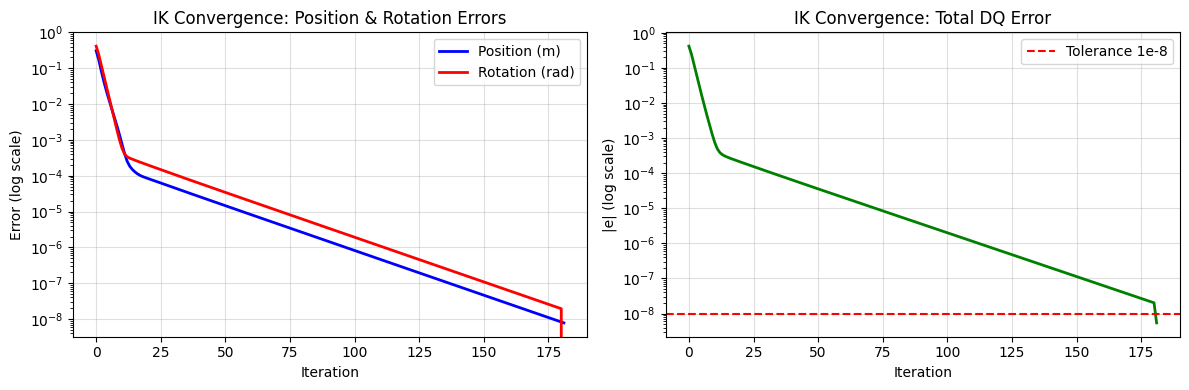


Final Results:
  Converged: True
  Position error: 0.000008 mm
  Rotation error: 0.000000 deg
  Solved joints:  [ 0.079953  0.140377 -0.304026  0.059333  0.035679 -0.214281]
  True joints:    [ 0.079953  0.140377 -0.304025  0.059333  0.035679 -0.214282]


In [18]:
# ============================================================
# PLOT IK CONVERGENCE HISTORY
# ============================================================

# Run one IK with verbose=True and plot convergence
theta_true = np.random.uniform(-np.pi*0.1, np.pi*0.1, 6)
#theta_true = np.array([0.5, -1.0, 0.8, -0.5, 1.2, 0.3])
Q_target   = fk_dq(S, theta_true, M_dq)
#theta_init = np.zeros(6)
theta_init = theta_true + np.random.uniform(-0.5, 0.5, 6)
theta_initf = np.clip(theta_init, UR5_Q_MIN_SAFE, UR5_Q_MAX_SAFE)

print('Running IK from all-zeros initial guess...')
theta_sol, converged, history = inverse_kinematics(
    S, M_dq, Q_target, theta_initf,
    tol=1e-8, max_iter=500, lam=0.05, alpha=0.5, verbose=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(history['iter'], history['pos_err'], 'b-', linewidth=2, label='Position (m)')
axes[0].semilogy(history['iter'], history['rot_err'], 'r-', linewidth=2, label='Rotation (rad)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Error (log scale)')
axes[0].set_title('IK Convergence: Position & Rotation Errors')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].semilogy(history['iter'], history['total_err'], 'g-', linewidth=2)
axes[1].axhline(y=1e-8, color='r', linestyle='--', label='Tolerance 1e-8')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('|e| (log scale)')
axes[1].set_title('IK Convergence: Total DQ Error')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Final verification
Q_final = fk_dq(S, theta_sol, M_dq)
pos_err, rot_err = pose_error_metrics(Q_final, Q_target)
print(f'\nFinal Results:')
print(f'  Converged: {converged}')
print(f'  Position error: {pos_err*1000:.6f} mm')
print(f'  Rotation error: {np.degrees(rot_err):.6f} deg')
print(f'  Solved joints:  {theta_sol}')
print(f'  True joints:    {theta_true}')

---
## PART 10 — SCLERP: SCREW LINEAR INTERPOLATION

**ScLERP** generates the geometrically optimal path between two poses.
It interpolates along a **screw motion** — the natural rigid body motion
that simultaneously rotates and translates along a single axis.

### Formula
$$\hat{Q}(t) = \hat{Q}_A \otimes (\hat{Q}_A^{-1} \otimes \hat{Q}_B)^t \qquad t \in [0,1]$$

### DQ Power via Screw Parameters
$$\hat{Q}^t = \exp(t \cdot \log(\hat{Q}))$$

### Minimum Jerk Time Parameterisation
$$s(\tau) = 10\tau^3 - 15\tau^4 + 6\tau^5, \qquad \tau = t/T$$

Properties: $s(0)=0$, $s(1)=1$, $\dot{s}(0)=\dot{s}(1)=0$, $\ddot{s}(0)=\ddot{s}(1)=0$

This gives **zero velocity AND acceleration** at start and end — critical
for smooth motor commands without jerks.


=== ScLERP Verification ===

ScLERP(t=0) == Q_A: max error = 0.00e+00   ✓
ScLERP(t=1) == Q_B: max error = 8.33e-17    ✓


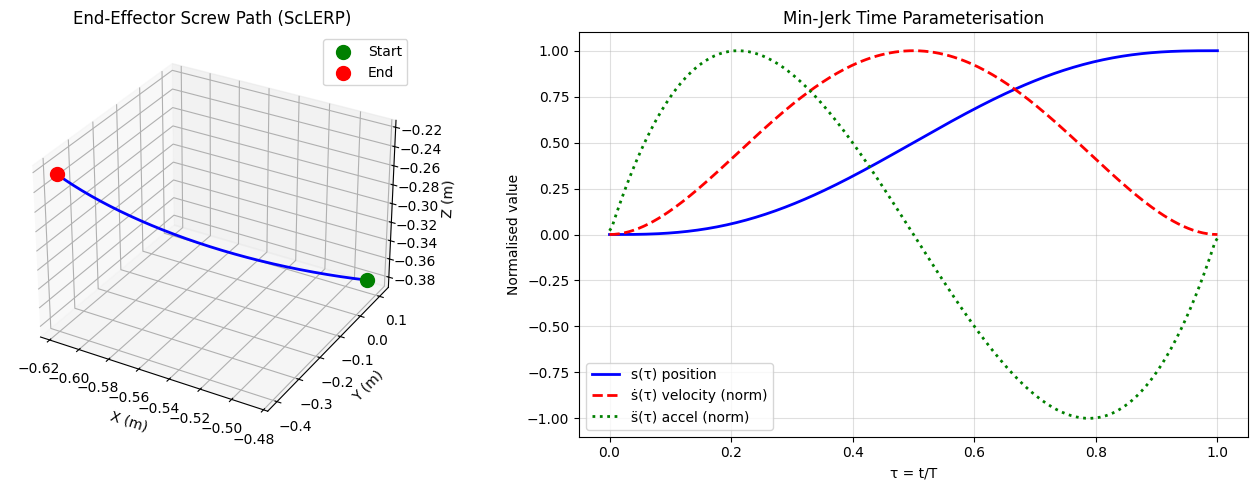


Trajectory: 250 poses generated
Path length: 555.97 mm


In [19]:
# ============================================================
# SCLERP — SCREW LINEAR INTERPOLATION
# ============================================================

def dq_power(Q, t):
    """
    Compute Q^t for a unit dual quaternion via screw decomposition.
    
    For unit DQ Q = q_r + eps*q_d:
      Extract screw parameters (angle theta, pitch d, axis omega, moment m)
      Scale by t
      Reconstruct DQ
    
    Parameters
    ----------
    Q : (8,) unit dual quaternion
    t : float  power parameter in [0,1]
    
    Returns
    -------
    (8,) dual quaternion Q^t
    """
    qr = Q[:4]
    qd = Q[4:]
    
    # Handle double cover
    if qr[0] < 0:
        qr, qd = -qr, -qd
    
    qrw = float(np.clip(qr[0], -1.0, 1.0))
    half_angle = np.arccos(qrw)   # theta/2
    
    if half_angle < 1e-10:
        # Near identity: linear interpolation of translation only
        qd_t = qd * t
        Q_t  = np.concatenate([[1., 0., 0., 0.], qd_t])
        return dq_normalize(Q_t)
    
    sin_ha    = np.sin(half_angle)
    omega_hat = qr[1:] / sin_ha    # unit rotation axis
    
    # Screw pitch: d = -2 * qdw / sin(half_angle)
    d_half  = -qd[0] / sin_ha
    
    # Moment: perpendicular component
    moment = (qd[1:] - d_half * qrw * omega_hat) / sin_ha
    
    # Scale screw parameters by t
    ha_t    = half_angle * t
    d_t_ha  = d_half * t
    
    c_t = np.cos(ha_t)
    s_t = np.sin(ha_t)
    
    # Reconstruct scaled DQ
    qr_t = np.array([c_t,
                      s_t * omega_hat[0],
                      s_t * omega_hat[1],
                      s_t * omega_hat[2]])
    
    qd_t = np.array([
        -d_t_ha * s_t,
         d_t_ha * c_t * omega_hat[0] + s_t * moment[0],
         d_t_ha * c_t * omega_hat[1] + s_t * moment[1],
         d_t_ha * c_t * omega_hat[2] + s_t * moment[2]
    ])
    
    return dq_normalize(np.concatenate([qr_t, qd_t]))


def sclerp(Q_A, Q_B, t):
    """
    Screw Linear Interpolation between poses Q_A and Q_B.
    
    Q(t) = Q_A ⊗ (Q_A^{-1} ⊗ Q_B)^t
    
    At t=0: returns Q_A exactly
    At t=1: returns Q_B exactly
    Traces the shortest screw motion between the two poses.
    
    Parameters
    ----------
    Q_A, Q_B : (8,) dual quaternions
    t        : float  parameter in [0,1]
    
    Returns
    -------
    (8,) interpolated dual quaternion
    """
    # Relative motion from A to B
    Q_rel = dq_multiply(dq_conjugate(Q_A), Q_B)
    
    # Handle double cover for relative motion
    if Q_rel[0] < 0:
        Q_rel = -Q_rel
    
    # Interpolate relative motion
    Q_rel_t = dq_power(Q_rel, t)
    
    # Apply to start pose
    return dq_normalize(dq_multiply(Q_A, Q_rel_t))


def min_jerk(tau):
    """
    Minimum jerk trajectory profile: s(tau) = 10t^3 - 15t^4 + 6t^5
    tau in [0,1], returns s in [0,1]
    Zero velocity and acceleration at start and end.
    """
    return 10*tau**3 - 15*tau**4 + 6*tau**5


def generate_trajectory(Q_start, Q_end, n_points=250):
    """
    Generate trajectory from Q_start to Q_end using ScLERP
    with minimum-jerk time parameterisation.
    
    Parameters
    ----------
    Q_start  : (8,)  start pose DQ
    Q_end    : (8,)  end pose DQ
    n_points : int   number of trajectory points (250 = 2s at 125Hz)
    
    Returns
    -------
    trajectory : list of (8,) DQ poses
    s_values   : (n_points,) time parameter values
    """
    s_vals = np.array([min_jerk(i / (n_points-1)) for i in range(n_points)])
    trajectory = [sclerp(Q_start, Q_end, s) for s in s_vals]
    return trajectory, s_vals


# ============================================================
# Verify ScLERP
# ============================================================
print('=== ScLERP Verification ===')
print()

theta_A = np.array([0.0, -np.pi/2, np.pi/2, -np.pi/2, -np.pi/2, 0.0])
theta_B = np.array([np.pi/4, -np.pi/3, np.pi/3, -np.pi/4, -np.pi/3, np.pi/6])

Q_A = fk_dq(S, theta_A, M_dq)
Q_B = fk_dq(S, theta_B, M_dq)

# Verify endpoints
Q_t0 = sclerp(Q_A, Q_B, 0.0)
Q_t1 = sclerp(Q_A, Q_B, 1.0)

err_start = np.max(np.abs(Q_t0 - dq_normalize(Q_A)))
err_end   = np.max(np.abs(Q_t1 - dq_normalize(Q_B)))
print(f'ScLERP(t=0) == Q_A: max error = {err_start:.2e}  ', '✓' if err_start < 1e-10 else '✗')
print(f'ScLERP(t=1) == Q_B: max error = {err_end:.2e}   ', '✓' if err_end < 1e-10 else '✗')

# Generate full trajectory
traj, s_vals = generate_trajectory(Q_A, Q_B, n_points=250)

# Extract positions for plotting
positions = np.array([dq_translation(q) for q in traj])

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(positions[:,0], positions[:,1], positions[:,2], 'b-', linewidth=2)
ax1.scatter(*positions[0], color='green', s=100, zorder=5, label='Start')
ax1.scatter(*positions[-1], color='red', s=100, zorder=5, label='End')
ax1.set_xlabel('X (m)'); ax1.set_ylabel('Y (m)'); ax1.set_zlabel('Z (m)')
ax1.set_title('End-Effector Screw Path (ScLERP)')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
tau_vals = np.linspace(0, 1, 250)
ax2.plot(tau_vals, s_vals, 'b-', linewidth=2, label='s(τ) position')
ds = np.gradient(s_vals, tau_vals)
ax2.plot(tau_vals, ds/ds.max(), 'r--', linewidth=2, label='ṡ(τ) velocity (norm)')
dds = np.gradient(ds, tau_vals)
ax2.plot(tau_vals, dds/np.max(np.abs(dds)), 'g:', linewidth=2, label='s̈(τ) accel (norm)')
ax2.set_xlabel('τ = t/T'); ax2.set_ylabel('Normalised value')
ax2.set_title('Min-Jerk Time Parameterisation')
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'\nTrajectory: {len(traj)} poses generated')
print(f'Path length: {np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1))*1000:.2f} mm')

---
## PART 11 — COMPLETE MOTION PLANNING PIPELINE

Now we chain everything together:

```
1. Define start/end poses in DQ space
2. ScLERP + min-jerk → 250 Cartesian DQ poses
3. IK at each pose → 250 joint angle sets
4. (Simulate) send to motors at 125 Hz
```

**Key insight:** Each IK call is warm-started from the **previous solution**,
so convergence typically takes only 1-5 iterations (not 100+).
This makes online trajectory execution feasible at 125 Hz.


Planning trajectory...

  Waypoint   0/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint  20/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint  40/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint  60/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint  80/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint 100/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint 120/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint 140/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint 160/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint 180/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint 200/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint 220/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint 240/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint 260/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
  Waypoint 280/500: pos_err=0.000mm  rot_err=0.000deg  conv=True
 

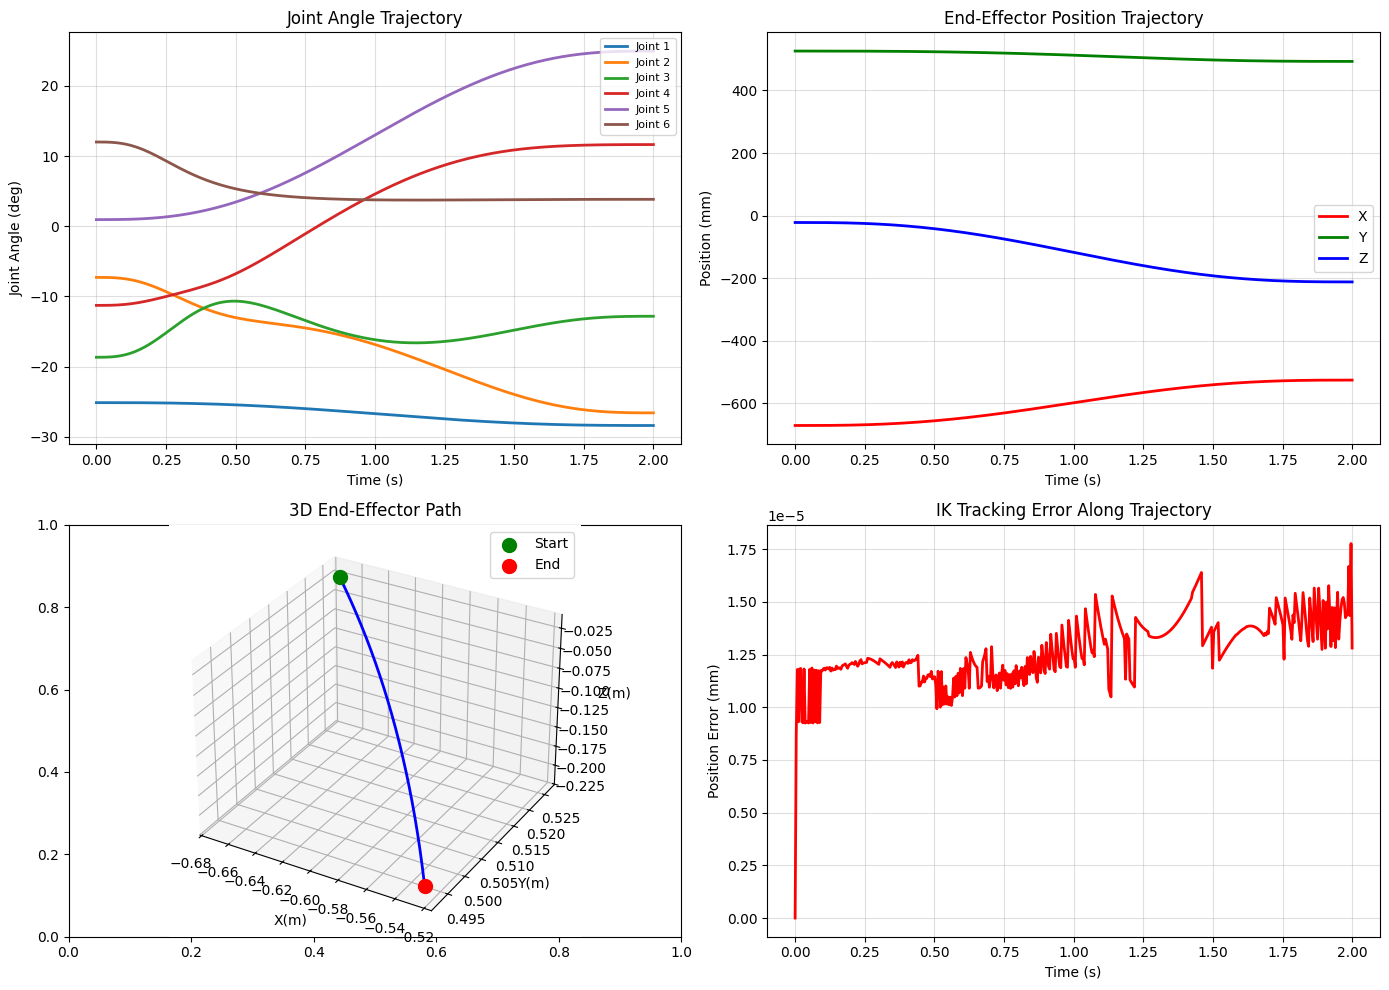


Trajectory Statistics:
  Waypoints:            500
  Mean IK error:        0.0000 mm
  Max IK error:         0.0000 mm
  Path length:          241.38 mm


In [21]:
# ============================================================
# COMPLETE MOTION PLANNING PIPELINE
# ============================================================

def plan_trajectory(S_axes, M_dq, theta_start, Q_end,
                    n_points=100, ik_tol=1e-8, verbose=True):
    """
    Plan a trajectory from current joint config to target DQ pose.
    
    Steps:
    1. FK from theta_start -> Q_start
    2. ScLERP(Q_start, Q_end, t) -> waypoints
    3. IK at each waypoint (warm-started from previous)
    
    Parameters
    ----------
    S_axes      : (6,6)  screw axes
    M_dq        : (8,)   home DQ
    theta_start : (6,)   starting joint angles
    Q_end       : (8,)   target end-effector DQ
    n_points    : int    number of trajectory waypoints
    ik_tol      : float  IK convergence tolerance per waypoint
    
    Returns
    -------
    theta_traj  : (n_points, 6)  joint angle trajectory
    pose_traj   : list of (8,) DQ poses along path
    ik_errors   : (n_points,) IK error at each point
    """
    # Step 1: Start pose from current joints
    Q_start = fk_dq(S_axes, theta_start, M_dq)
    
    # Step 2: Generate ScLERP trajectory
    pose_traj, s_vals = generate_trajectory(Q_start, Q_end, n_points=n_points)
    
    # Step 3: IK at each waypoint
    theta_traj = np.zeros((n_points, 6))
    ik_errors  = np.zeros(n_points)
    theta_traj[0] = theta_start
    
    theta_prev = theta_start.copy()
    
    for i, Q_wp in enumerate(pose_traj):
        # Warm start from previous solution
        theta_sol, conv, hist = inverse_kinematics(
            S_axes, M_dq, Q_wp, theta_prev,
            tol=ik_tol, max_iter=500,
            lam=0.05, alpha=0.5   # tighter params for warm-started IK
        )
        theta_traj[i] = theta_sol
        
        # Measure actual FK error at this point
        Q_actual = fk_dq(S_axes, theta_sol, M_dq)
        pos_e, rot_e = pose_error_metrics(Q_actual, Q_wp)
        ik_errors[i] = pos_e * 1000   # mm
        
        theta_prev = theta_sol.copy()  # warm start next iter
        
        if verbose and i % 20 == 0:
            print(f'  Waypoint {i:3d}/{n_points}: pos_err={pos_e*1000:.3f}mm  '
                  f'rot_err={np.degrees(rot_e):.3f}deg  conv={conv}')
    
    return theta_traj, pose_traj, ik_errors


# ============================================================
# Run complete trajectory
# ============================================================
print('Planning trajectory...')
print()

s_pos = np.random.uniform(-np.pi*0.2, np.pi*0.2, 6)
#theta_start = np.array([0.0, -np.pi/2, np.pi/2, -np.pi/2, -np.pi/2, 0.0])
theta_start = s_pos
e_pos = np.random.uniform(-np.pi*0.2, np.pi*0.2, 6)
#theta_end   = np.array([np.pi/3, -np.pi/4, np.pi/4, -np.pi/3, -np.pi/4, np.pi/6])
theta_end = e_pos
Q_end_target = fk_dq(S, theta_end, M_dq)

theta_traj, pose_traj, ik_errors = plan_trajectory(
    S, M_dq, theta_start, Q_end_target,
    n_points=500, ik_tol=1e-8, verbose=True
)

# ============================================================
# Plot trajectory results
# ============================================================
positions_traj = np.array([dq_translation(q) for q in pose_traj])
time_axis = np.linspace(0, 2.0, len(pose_traj))   # 2 second motion

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Joint angles over time
labels_j = ['Joint 1','Joint 2','Joint 3','Joint 4','Joint 5','Joint 6']
for j in range(6):
    axes[0,0].plot(time_axis, np.degrees(theta_traj[:, j]), linewidth=2, label=labels_j[j])
axes[0,0].set_xlabel('Time (s)'); axes[0,0].set_ylabel('Joint Angle (deg)')
axes[0,0].set_title('Joint Angle Trajectory')
axes[0,0].legend(loc='upper right', fontsize=8); axes[0,0].grid(True, alpha=0.4)

# End-effector position over time
axes[0,1].plot(time_axis, positions_traj[:,0]*1000, 'r-', linewidth=2, label='X')
axes[0,1].plot(time_axis, positions_traj[:,1]*1000, 'g-', linewidth=2, label='Y')
axes[0,1].plot(time_axis, positions_traj[:,2]*1000, 'b-', linewidth=2, label='Z')
axes[0,1].set_xlabel('Time (s)'); axes[0,1].set_ylabel('Position (mm)')
axes[0,1].set_title('End-Effector Position Trajectory')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.4)

# 3D path
ax3d = fig.add_subplot(2, 2, 3, projection='3d')
ax3d.plot(positions_traj[:,0], positions_traj[:,1], positions_traj[:,2],
           'b-', linewidth=2)
ax3d.scatter(*positions_traj[0],  color='green', s=100, label='Start')
ax3d.scatter(*positions_traj[-1], color='red',   s=100, label='End')
ax3d.set_xlabel('X(m)'); ax3d.set_ylabel('Y(m)'); ax3d.set_zlabel('Z(m)')
ax3d.set_title('3D End-Effector Path')
ax3d.legend()

# IK errors along trajectory
axes[1,1].plot(time_axis, ik_errors, 'r-', linewidth=2)
axes[1,1].set_xlabel('Time (s)'); axes[1,1].set_ylabel('Position Error (mm)')
axes[1,1].set_title('IK Tracking Error Along Trajectory')
axes[1,1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'\nTrajectory Statistics:')
print(f'  Waypoints:            {len(pose_traj)}')
print(f'  Mean IK error:        {ik_errors.mean():.4f} mm')
print(f'  Max IK error:         {ik_errors.max():.4f} mm')
print(f'  Path length:          {np.sum(np.linalg.norm(np.diff(positions_traj, axis=0), axis=1))*1000:.2f} mm')

---
## PART 12 — NEURAL NETWORK IK

### Design Choices

| Choice | What | Why |
|--------|------|-----|
| **Input** | DQ (8D) | Singularity-free, encodes rotation without discontinuities |
| **Output** | θ (6D) | Unconstrained, minimal, directly maps to motor commands |
| **Activation** | Swish | Better than ReLU for smooth functions (no dead neurons) |
| **Normalisation** | BatchNorm | Stabilises training, faster convergence |
| **Loss** | MSE on joint angles | Simple, effective; pose loss added via FK verification |
| **Data** | 200k samples | Enough to cover the 6D joint space adequately |

### Why DQ input is better than [x,y,z,rx,ry,rz]
- Axis-angle has singularity at θ=0 and discontinuity near θ=±π
- Euler angles have gimbal lock
- DQ real part is continuous on the unit 3-sphere (S³) — smooth everywhere
- The network can learn orientation without fighting representation artifacts

### Hybrid approach
NN gives a fast warm start → numerical IK refines to machine precision.
This combines NN speed (~1ms) with numerical accuracy (1e-8 m).


In [23]:
# ============================================================
# DATASET GENERATION
# Input:  end-effector DQ (8 numbers) - singularity-free pose
# Output: joint angles theta (6 numbers) plus pose targets for FK loss
# ============================================================

print('Generating training dataset...')

N_SAMPLES = 1000000   # number of (pose, joints) pairs

# Training joint limits - slightly inside hardware limits for safety
TRAIN_LIMITS = np.array([
    [-np.pi*0.9,  np.pi*0.9],   # Joint 1
    [-np.pi*0.9,  np.pi*0.9],   # Joint 2
    [-np.pi*0.9,  np.pi*0.9],   # Joint 3
    [-np.pi*0.9,  np.pi*0.9],   # Joint 4
    [-np.pi*0.9,  np.pi*0.9],   # Joint 5
    [-np.pi*0.9,  np.pi*0.9],   # Joint 6
])

np.random.seed(42)

X_dq      = np.zeros((N_SAMPLES, 8), dtype=np.float64)
Y_theta   = np.zeros((N_SAMPLES, 6), dtype=np.float64)
Y_pose    = np.zeros((N_SAMPLES, 12), dtype=np.float64)
manip_idx = np.zeros((N_SAMPLES,), dtype=np.float64)
branch_id = np.zeros((N_SAMPLES,), dtype=np.int64)

for i in tqdm(range(N_SAMPLES), desc='Generating samples', unit='sample'):
    theta_rand = np.array([
        np.random.uniform(lo, hi)
        for lo, hi in TRAIN_LIMITS
    ], dtype=np.float64)

    # Forward kinematics -> end-effector DQ
    Q_ee = fk_dq(S, theta_rand, M_dq)
    if Q_ee[0] < 0:
        Q_ee = -Q_ee

    X_dq[i] = Q_ee
    Y_theta[i] = theta_rand

    # Pose targets for FK loss: position + rotation matrix
    pos = dq_translation(Q_ee)
    R   = dq_rotation_matrix(Q_ee)
    Y_pose[i, :3] = pos
    Y_pose[i, 3:] = R.reshape(-1)

    # Approximate manipulability as abs(det(J)) for speed
    J = jacobian_6x6(S, theta_rand, M_dq)
    manip_idx[i] = max(np.abs(np.linalg.det(J)), 1e-16)

    # Simple branch signature to inspect configuration variety
    branch_id[i] = int((theta_rand[1] > 0) * 1 +
                       (theta_rand[3] > 0) * 2 +
                       (theta_rand[5] > 0) * 4)

print(f'Dataset shape: X={X_dq.shape}, Y_theta={Y_theta.shape}, Y_pose={Y_pose.shape}')
print()
# Verify DQ constraints in dataset
norms  = np.linalg.norm(X_dq[:, :4], axis=1)
orthos = np.sum(X_dq[:, :4] * X_dq[:, 4:], axis=1)
print(f'DQ real part norms:    mean={norms.mean():.6f}, std={norms.std():.6f}  (should be 1.0)')
print(f'DQ orthogonality:      max|q_r·q_d|={np.max(np.abs(orthos)):.2e}  (should be ~0)')
print()
print(f'Joint angle ranges in dataset:')
for j in range(6):
    print(f'  Joint {j+1}: [{Y_theta[:,j].min():.3f}, {Y_theta[:,j].max():.3f}] rad')
print()
print(f'Manipulability index:  mean={manip_idx.mean():.6e}, std={manip_idx.std():.6e}')
print(f'Branch distribution:   {np.unique(branch_id, return_counts=True)}')


Generating training dataset...


Generating samples: 100%|██████████| 1000000/1000000 [17:26<00:00, 955.70sample/s]


Dataset shape: X=(1000000, 8), Y_theta=(1000000, 6), Y_pose=(1000000, 12)

DQ real part norms:    mean=1.000000, std=0.000000  (should be 1.0)
DQ orthogonality:      max|q_r·q_d|=1.11e-16  (should be ~0)

Joint angle ranges in dataset:
  Joint 1: [-2.827, 2.827] rad
  Joint 2: [-2.827, 2.827] rad
  Joint 3: [-2.827, 2.827] rad
  Joint 4: [-2.827, 2.827] rad
  Joint 5: [-2.827, 2.827] rad
  Joint 6: [-2.827, 2.827] rad

Manipulability index:  mean=2.776690e-02, std=2.542911e-02
Branch distribution:   (array([0, 1, 2, 3, 4, 5, 6, 7]), array([125232, 124896, 124535, 125724, 125003, 125622, 124434, 124554]))


In [24]:
# ============================================================
# DATA NORMALISATION
# DQ input: real part on unit sphere (already bounded [-1,1])
#           dual part range depends on robot scale
# We normalise the dual part and joint angles,
# but keep real quaternion raw (it's already unit norm)
# ============================================================

# Split X into real and dual parts
X_real = X_dq[:, :4]   # unit quaternion part
X_dual = X_dq[:, 4:]   # dual part (scale with robot geometry)

# Normalise only the dual part (real part is already on unit sphere)
X_dual_mean = X_dual.mean(axis=0)
X_dual_std  = X_dual.std(axis=0) + 1e-8
X_dual_norm = (X_dual - X_dual_mean) / X_dual_std

# Combine: real part unchanged, dual part normalised
X_input = np.hstack([X_real, X_dual_norm])   # (N, 8)

# Normalise joint angles (they span [-pi*0.9, pi*0.9])
Y_mean = Y_theta.mean(axis=0)
Y_std  = Y_theta.std(axis=0) + 1e-8
Y_norm = (Y_theta - Y_mean) / Y_std

# Build combined label tensor for angle supervision + FK pose loss
Y_combined = np.hstack([Y_norm, Y_pose])   # (N, 18)

# Train/validation split (90/10)
n_val  = N_SAMPLES // 10
n_train = N_SAMPLES - n_val

idx = np.random.permutation(N_SAMPLES)
train_idx = idx[:n_train]
val_idx   = idx[n_train:]

X_train, X_val = X_input[train_idx], X_input[val_idx]
Y_train, Y_val = Y_combined[train_idx], Y_combined[val_idx]

# Emphasize low-manipulability examples during training
manip_min, manip_max = manip_idx.min(), manip_idx.max()
manip_weight = 1.0 + (manip_max - manip_idx) / (manip_max - manip_min + 1e-8)
manip_weight = np.clip(manip_weight, 0.5, 5.0)
train_sample_weight = manip_weight[train_idx]
val_sample_weight   = manip_weight[val_idx]

print(f'Training samples:   {X_train.shape[0]}')
print(f'Validation samples: {X_val.shape[0]}')
print(f'Input features:     {X_train.shape[1]}  (8D DQ: 4 real + 4 dual)')
print(f'Output features:    {Y_train.shape[1]}  (6 normalized joints + 12 pose targets)')
print(f'Sample weight range:{train_sample_weight.min():.3f} to {train_sample_weight.max():.3f}')


Training samples:   900000
Validation samples: 100000
Input features:     8  (8D DQ: 4 real + 4 dual)
Output features:    18  (6 normalized joints + 12 pose targets)
Sample weight range:1.000 to 2.000


In [26]:
# ============================================================
# NEURAL NETWORK ARCHITECTURE
#
# Input:  8D (DQ representation of end-effector pose)
# Output: 6D (joint angles theta_1 ... theta_6)
#
# Architecture: Deep MLP with BatchNorm and Swish activation
# Swish = x * sigmoid(x) — smoother than ReLU, better for regression
# BatchNorm — normalises activations, prevents vanishing gradients
# ============================================================

def build_ik_network(input_dim=8, output_dim=6):
    """
    Build the IK neural network.
    
    Architecture:
    Input(8) -> Dense(512,swish)->BN -> Dense(512,swish)->BN
             -> Dense(256,swish)->BN -> Dense(256,swish)
             -> Dense(128,swish) -> Dense(6)
    
    Total parameters: ~560k
    """
    inp = Input(shape=(input_dim,), name='dq_pose_input')
    
    # Block 1
    x = Dense(512, activation='swish', name='dense_1')(inp)
    x = BatchNormalization(name='bn_1')(x)
    
    # Block 2
    x = Dense(512, activation='swish', name='dense_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    
    # Block 3
    x = Dense(256, activation='swish', name='dense_3')(x)
    x = BatchNormalization(name='bn_3')(x)
    
    # Block 4
    x = Dense(256, activation='swish', name='dense_4')(x)
    
    # Block 5
    x = Dense(128, activation='swish', name='dense_5')(x)
    
    # Output: no activation (joint angles are unbounded within limits)
    out = Dense(output_dim, name='joint_angles')(x)
    
    model = Model(inp, out, name='UR5_IK_Network')
    return model


# Build and compile
ik_model = build_ik_network()
ik_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

ik_model.summary()

print(f'\nTotal parameters: {ik_model.count_params():,}')

Model: "UR5_IK_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dq_pose_input (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ joint_angles (Dense)            │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,174 (1.92 MB)

 Trainable params: 500,614 (1.91 MB)

 Non-trainable params: 2,560 (10.00 KB)


Total parameters: 503,174


In [27]:
# ============================================================
# TRAINING
# ============================================================

# Convert the DH parameters to TensorFlow constants for differentiable FK
DH_a_tf     = tf.constant(DH_a, dtype=tf.float32)
DH_alpha_tf = tf.constant(DH_alpha, dtype=tf.float32)
DH_d_tf     = tf.constant(DH_d, dtype=tf.float32)
Y_mean_tf   = tf.constant(Y_mean, dtype=tf.float32)
Y_std_tf    = tf.constant(Y_std, dtype=tf.float32)


def dh_tf_matrix(a, alpha, d, theta):
    ct = tf.cos(theta)
    st = tf.sin(theta)
    ca = tf.cos(alpha)
    sa = tf.sin(alpha)
    zeros = tf.zeros_like(theta)
    return tf.stack([
        tf.stack([ct, -st, zeros, tf.fill(tf.shape(theta), a)], axis=-1),
        tf.stack([st * ca, ct * ca, -sa * tf.ones_like(theta), -d * sa * tf.ones_like(theta)], axis=-1),
        tf.stack([st * sa, ct * sa, ca * tf.ones_like(theta), d * ca * tf.ones_like(theta)], axis=-1),
        tf.stack([zeros, zeros, zeros, tf.ones_like(theta)], axis=-1),
    ], axis=-2)


def fk_tf(theta_pred):
    batch_size = tf.shape(theta_pred)[0]
    T = tf.eye(4, batch_shape=[batch_size], dtype=tf.float32)
    for i in range(6):
        Ti = dh_tf_matrix(DH_a_tf[i], DH_alpha_tf[i], DH_d_tf[i], theta_pred[:, i])
        T = tf.matmul(T, Ti)
    pos = T[:, :3, 3]
    rot = T[:, :3, :3]
    return pos, rot


def fk_pose_loss(y_true, y_pred):
    # y_true: [theta_norm (6), target_pos (3), target_R (9)]
    theta_norm_true = y_true[:, :6]
    target_pos = y_true[:, 6:9]
    target_R = tf.reshape(y_true[:, 9:], (-1, 3, 3))

    theta_pred = y_pred * Y_std_tf + Y_mean_tf
    pos_pred, R_pred = fk_tf(theta_pred)

    angle_loss = tf.reduce_mean(tf.square(theta_norm_true - y_pred), axis=-1)
    pos_loss   = tf.reduce_mean(tf.square(pos_pred - target_pos), axis=-1)
    rot_loss   = tf.reduce_mean(tf.square(R_pred - target_R), axis=[1, 2])

    return 0.3 * angle_loss + 10.0 * pos_loss + 5.0 * rot_loss


def angle_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true[:, :6] - y_pred), axis=-1)


callbacks = [
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    ),
    # Stop early if no improvement for 30 epochs, restore best weights
    EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        verbose=1
    )
]

print('Training NN IK model...')
print('(Input: 8D DQ pose | Output: 6D joint angles with FK pose regularization)')
print()
BATCH_SIZE = 256
TRAIN_EPOCHS = 100


ik_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=fk_pose_loss,
    metrics=[angle_mae]
)

history_nn = ik_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val, val_sample_weight),
    sample_weight=train_sample_weight,
    batch_size=BATCH_SIZE,
    epochs=TRAIN_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print('Training complete.')


Training NN IK model...
(Input: 8D DQ pose | Output: 6D joint angles with FK pose regularization)

Epoch 1/100
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 74s 20ms/step - angle_mae: 0.9442 - loss: 1.3890 - val_angle_mae: 0.9353 - val_loss: 1.1747 - learning_rate: 0.0010
Epoch 2/100
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 69s 20ms/step - angle_mae: 0.9318 - loss: 1.1312 - val_angle_mae: 0.9300 - val_loss: 1.0775 - learning_rate: 0.0010
Epoch 3/100
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 70s 20ms/step - angle_mae: 0.9284 - loss: 1.0944 - val_angle_mae: 0.9269 - val_loss: 1.0610 - learning_rate: 0.0010
Epoch 4/100
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 84s 21ms/step - angle_mae: 0.9230 - loss: 1.0683 - val_angle_mae: 0.9237 - val_loss: 1.0314 - learning_rate: 0.0010
Epoch 5/100
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 79s 20ms/step - angle_mae: 0.9216 - loss: 1.0541 - val_angle_mae: 0.9170 - val_loss: 1.0054 - learning_rate: 0.0010
Epoch 6/100
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 84s 20ms/step - angle_mae: 0.9201 - loss: 1.0373 - val_angle_ma

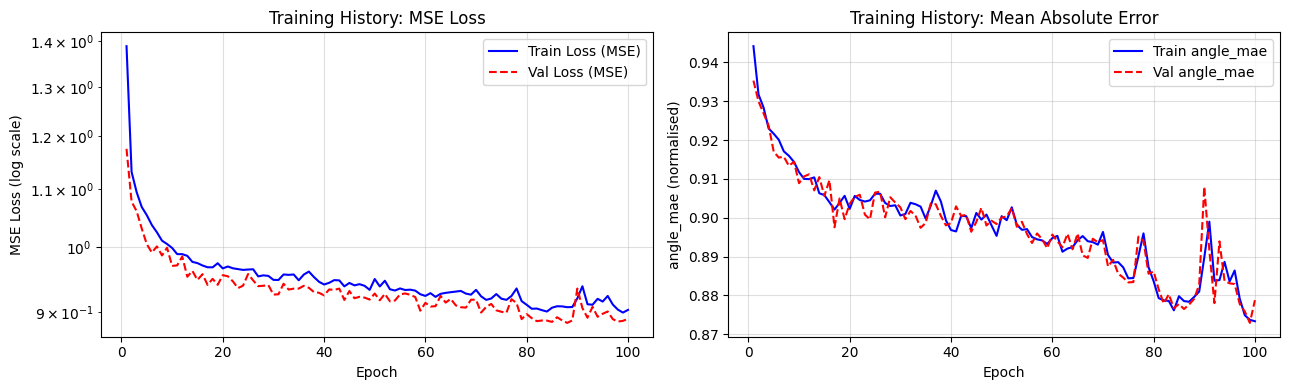

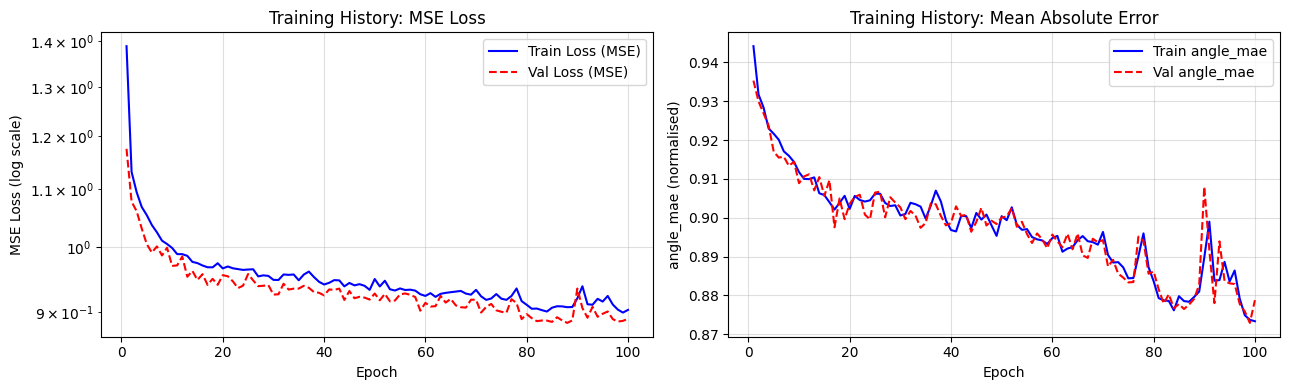

In [28]:
# ============================================================
# PLOT TRAINING HISTORY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(history_nn.history['loss']) + 1)
metric_name = 'angle_mae' if 'angle_mae' in history_nn.history else 'mae'
val_metric_name = 'val_' + metric_name

axes[0].semilogy(epochs, history_nn.history['loss'],     'b-',  label='Train Loss (MSE)')
axes[0].semilogy(epochs, history_nn.history['val_loss'], 'r--', label='Val Loss (MSE)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss (log scale)')
axes[0].set_title('Training History: MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs, history_nn.history[metric_name],     'b-',  label=f'Train {metric_name}')
axes[1].plot(epochs, history_nn.history[val_metric_name], 'r--', label=f'Val {metric_name}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel(f'{metric_name} (normalised)')
axes[1].set_title('Training History: Mean Absolute Error')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
display(fig)


In [29]:
# ============================================================
# HYBRID IK SOLVER
# NN warm start + DQ numerical refinement
# ============================================================

def dq_to_nn_input(Q_ee, X_dual_mean, X_dual_std):
    """
    Convert end-effector DQ to normalised NN input.
    Real part: kept raw (already on unit sphere)
    Dual part: normalised using training statistics
    """
    Q = Q_ee.copy()
    if Q[0] < 0:
        Q = -Q   # canonical form
    qr = Q[:4]
    qd = (Q[4:] - X_dual_mean) / X_dual_std
    return np.concatenate([qr, qd])


def nn_predict_joints(Q_target, model, X_dual_mean, X_dual_std, Y_mean, Y_std):
    """
    Use neural network to predict joint angles from target DQ.
    Returns raw (unnormalised) joint angles.
    """
    x = dq_to_nn_input(Q_target, X_dual_mean, X_dual_std).reshape(1, -1)
    y_norm = model.predict(x, verbose=0)[0]
    return y_norm * Y_std + Y_mean   # denormalise


def hybrid_ik(Q_target, S_axes, M_dq, model,
              X_dual_mean, X_dual_std, Y_mean, Y_std,
              refine_tol=1e-8, refine_max_iter=50):
    """
    Hybrid IK: NN warm start + numerical DQ refinement.
    
    Step 1: NN predicts theta_init from Q_target (fast, ~1ms)
    Step 2: DQ Newton-Raphson refines from theta_init to tolerance
    
    Returns
    -------
    theta_final : (6,) refined joint angles
    nn_pos_err  : float  NN-only position error (mm)
    final_pos_err : float  after refinement (mm)
    """
    # Step 1: NN prediction
    theta_nn = nn_predict_joints(Q_target, model,
                                  X_dual_mean, X_dual_std, Y_mean, Y_std)
    theta_nn = np.clip(theta_nn, UR5_Q_MIN_SAFE, UR5_Q_MAX_SAFE)
    
    # NN-only error
    Q_nn = fk_dq(S_axes, theta_nn, M_dq)
    nn_pos_err, nn_rot_err = pose_error_metrics(Q_nn, Q_target)
    
    # Step 2: Numerical refinement from NN guess
    theta_final, converged, _ = inverse_kinematics(
        S_axes, M_dq, Q_target, theta_nn,
        tol=refine_tol, max_iter=refine_max_iter,
        lam=0.05, alpha=0.5
    )
    
    # Final error
    Q_final = fk_dq(S_axes, theta_final, M_dq)
    final_pos_err, final_rot_err = pose_error_metrics(Q_final, Q_target)
    
    return theta_final, nn_pos_err*1000, final_pos_err*1000


print('Hybrid IK solver defined.')
print('Phase 1: NN prediction (~1ms, warm start)')
print('Phase 2: DQ numerical refinement to 1e-8 m precision')

Hybrid IK solver defined.
Phase 1: NN prediction (~1ms, warm start)
Phase 2: DQ numerical refinement to 1e-8 m precision


In [30]:
# ============================================================
# COMPREHENSIVE EVALUATION
# Compare: NN-only, Canonical IK branch, Numerical-only, Hybrid, and NN+FK verification
# ============================================================

print('=== Comprehensive IK Evaluation ===')
print()

N_EVAL = 100
np.random.seed(999)

fk_verify_pos_thresh = 0.003  # 3 mm
fk_verify_rot_thresh = np.deg2rad(1.0)  # 1 degree

results = {
    'nn_pos':       [],
    'nn_rot':       [],
    'canon_pos':    [],
    'canon_rot':    [],
    'num_pos':      [],
    'num_rot':      [],
    'hybrid_pos':   [],
    'hybrid_rot':   [],
    'verified_pos': [],
    'verified_rot': [],
    'num_iters':    [],
    'hyb_iters':    [],
    'verify_triggers': []
}

for i in range(N_EVAL):
    theta_true = np.random.uniform(-np.pi*0.8, np.pi*0.8, 6)
    Q_target   = fk_dq(S, theta_true, M_dq)

    # --- NN only ---
    theta_nn = nn_predict_joints(Q_target, ik_model,
                                 X_dual_mean, X_dual_std, Y_mean, Y_std)
    Q_nn = fk_dq(S, theta_nn, M_dq)
    p_nn, r_nn = pose_error_metrics(Q_nn, Q_target)
    results['nn_pos'].append(p_nn * 1000)
    results['nn_rot'].append(np.degrees(r_nn))

    # --- Canonical IK branch ---
    theta_canon, converged_canon, _ = inverse_kinematics(
        S, M_dq, Q_target, np.zeros(6),
        tol=1e-7, max_iter=500, lam=0.1, alpha=0.5
    )
    if not converged_canon:
        theta_canon, converged_canon, _ = inverse_kinematics(
            S, M_dq, Q_target, UR5_Q_MID,
            tol=1e-7, max_iter=500, lam=0.1, alpha=0.5
        )
    theta_canon = np.clip(theta_canon, UR5_Q_MIN_SAFE, UR5_Q_MAX_SAFE)
    Q_canon = fk_dq(S, theta_canon, M_dq)
    p_canon, r_canon = pose_error_metrics(Q_canon, Q_target)
    results['canon_pos'].append(p_canon * 1000)
    results['canon_rot'].append(np.degrees(r_canon))

    # --- Numerical IK from zero (cold start) ---
    theta_num, converged_num, hist_num = inverse_kinematics(
        S, M_dq, Q_target, np.zeros(6),
        tol=1e-7, max_iter=500, lam=0.05, alpha=0.5
    )
    Q_num = fk_dq(S, theta_num, M_dq)
    p_num, r_num = pose_error_metrics(Q_num, Q_target)
    results['num_pos'].append(p_num * 1000)
    results['num_rot'].append(np.degrees(r_num))
    results['num_iters'].append(len(hist_num['iter']))

    # --- Hybrid: NN warm start + numerical refinement ---
    theta_hyb, converged_hyb, hist_hyb = inverse_kinematics(
        S, M_dq, Q_target, theta_nn,
        tol=1e-8, max_iter=500, lam=0.05, alpha=0.5
    )
    Q_hyb = fk_dq(S, theta_hyb, M_dq)
    p_hyb, r_hyb = pose_error_metrics(Q_hyb, Q_target)
    results['hybrid_pos'].append(p_hyb * 1000)
    results['hybrid_rot'].append(np.degrees(r_hyb))
    results['hyb_iters'].append(len(hist_hyb['iter']))

    # --- NN verified with FK check and IK fallback ---
    use_fallback = (p_nn > fk_verify_pos_thresh or r_nn > fk_verify_rot_thresh)
    if use_fallback:
        theta_verified, converged_verified, hist_verified = inverse_kinematics(
            S, M_dq, Q_target, theta_nn,
            tol=1e-8, max_iter=500, lam=0.05, alpha=0.5
        )
        theta_verified = np.clip(theta_verified, UR5_Q_MIN_SAFE, UR5_Q_MAX_SAFE)
    else:
        theta_verified = theta_nn
        hist_verified = {'iter': []}

    Q_verified = fk_dq(S, theta_verified, M_dq)
    p_verified, r_verified = pose_error_metrics(Q_verified, Q_target)
    results['verified_pos'].append(p_verified * 1000)
    results['verified_rot'].append(np.degrees(r_verified))
    results['verify_triggers'].append(use_fallback)


# ============================================================
# Summary table and verification metrics
# ============================================================

def print_metrics(name, pos, rot):
    print(f'{name:<18} '
          f'{np.mean(pos):>10.4f} {np.max(pos):>11.4f} '
          f'{np.percentile(pos, 95):>10.4f} '
          f'{np.mean(rot):>11.6f} {np.max(rot):>11.4f}')

print(f'Evaluation over {N_EVAL} random reachable targets')
print('Method            Mean Pos  Max Pos  95% Pos   Mean Rot  Max Rot')
print('-' * 70)
print_metrics('NN only',       results['nn_pos'],     results['nn_rot'])
print_metrics('Canonical IK',  results['canon_pos'],  results['canon_rot'])
print_metrics('Numerical cold',results['num_pos'],    results['num_rot'])
print_metrics('Hybrid',        results['hybrid_pos'], results['hybrid_rot'])
print_metrics('NN verified',   results['verified_pos'], results['verified_rot'])

trigger_rate = np.mean(results['verify_triggers']) * 100
print(f'FK verification trigger rate: {trigger_rate:.1f}% of cases (pos > {fk_verify_pos_thresh*1000:.1f}mm or rot > {np.degrees(fk_verify_rot_thresh):.1f}°)')
print(f'Average cold-start iterations: {np.mean(results["num_iters"]):.1f}')
print(f'Average hybrid refinement iterations: {np.mean(results["hyb_iters"]):.1f}')



=== Comprehensive IK Evaluation ===

Evaluation over 100 random reachable targets
Method            Mean Pos  Max Pos  95% Pos   Mean Rot  Max Rot
----------------------------------------------------------------------
NN only              132.9101    275.3215   224.2397   98.666927    178.5508
Canonical IK          77.0582    751.5368   374.4205    7.727603     86.8882
Numerical cold        99.2380    782.8552   476.8408   11.972617     68.2271
Hybrid               205.4717   1434.1250   837.1113   19.197800     90.6743
NN verified          205.4717   1434.1250   837.1113   19.197800     90.6743
FK verification trigger rate: 100.0% of cases (pos > 3.0mm or rot > 1.0°)
Average cold-start iterations: 276.1
Average hybrid refinement iterations: 303.8


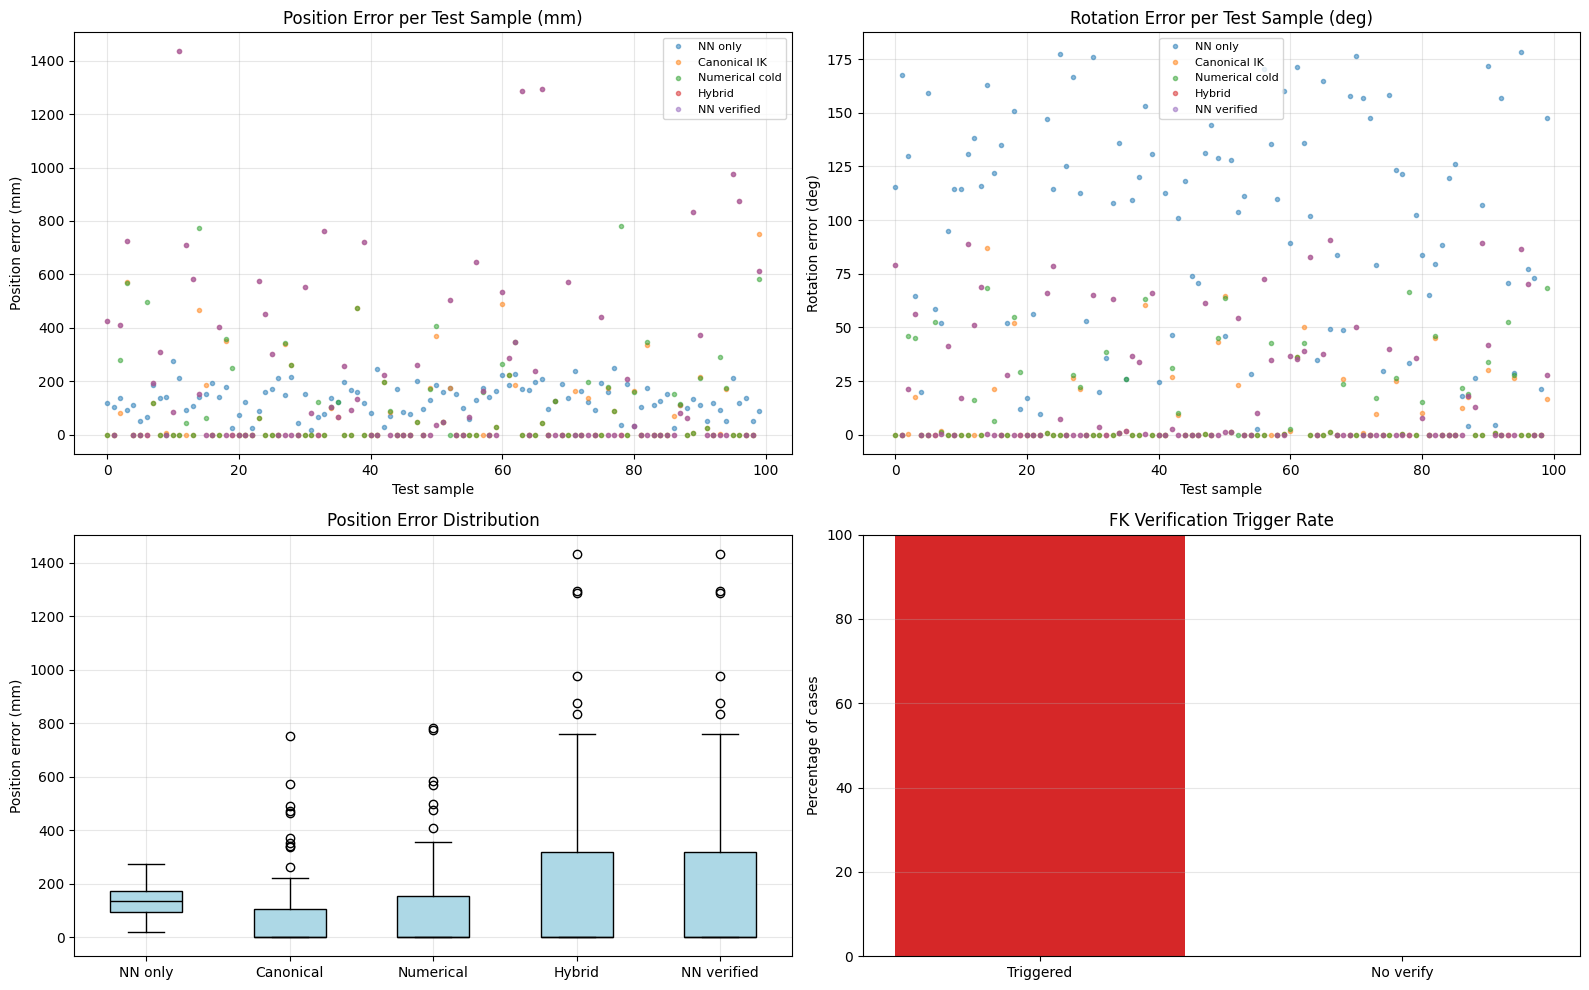

In [31]:
# ============================================================
# VISUALISE EVALUATION RESULTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
methods = [
    ('NN only',       results['nn_pos'],     results['nn_rot']),
    ('Canonical IK',  results['canon_pos'],  results['canon_rot']),
    ('Numerical cold',results['num_pos'],    results['num_rot']),
    ('Hybrid',        results['hybrid_pos'], results['hybrid_rot']),
    ('NN verified',   results['verified_pos'], results['verified_rot'])
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, (label, pos, rot) in enumerate(methods):
    axes[0,0].plot(range(len(pos)), pos, '.', alpha=0.5, label=label, color=colors[idx])
    axes[0,1].plot(range(len(rot)), rot, '.', alpha=0.5, label=label, color=colors[idx])

axes[0,0].set_title('Position Error per Test Sample (mm)')
axes[0,0].set_xlabel('Test sample')
axes[0,0].set_ylabel('Position error (mm)')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].set_title('Rotation Error per Test Sample (deg)')
axes[0,1].set_xlabel('Test sample')
axes[0,1].set_ylabel('Rotation error (deg)')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

box_data = [results['nn_pos'], results['canon_pos'], results['num_pos'], results['hybrid_pos'], results['verified_pos']]
labels = ['NN only', 'Canonical', 'Numerical', 'Hybrid', 'NN verified']
axes[1,0].boxplot(box_data, labels=labels, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='black'),
                   medianprops=dict(color='black'))
axes[1,0].set_title('Position Error Distribution')
axes[1,0].set_ylabel('Position error (mm)')
axes[1,0].grid(True, alpha=0.3)

trigger_pct = np.mean(results['verify_triggers']) * 100
axes[1,1].bar(['Triggered', 'No verify'], [trigger_pct, 100-trigger_pct], color=['#d62728', '#1f77b4'])
axes[1,1].set_ylim(0, 100)
axes[1,1].set_ylabel('Percentage of cases')
axes[1,1].set_title('FK Verification Trigger Rate')
axes[1,1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



---
## PART 13 — MOTOR COMMAND PIPELINE (SIMULATION)

This simulates what would run on real hardware at **125 Hz** (every 8ms).

The control loop:
```
READ encoders -> theta_actual
LOOKUP theta_ref(t) from precomputed trajectory
COMPUTE error: e = theta_ref - theta_actual
PID -> torque command tau
CONVERT tau -> motor current I
SEND I to motor driver
```

For real deployment, the trajectory (`theta_traj`) computed in Part 11
is sent to this loop. Each row is one timestep's reference.


In [32]:
# ============================================================
# SIMULATED MOTOR CONTROL LOOP
# ============================================================

class PIDController:
    """
    PD controller per joint (I term omitted for simulation clarity).
    Real UR5 uses more sophisticated control, but this illustrates the concept.
    """
    def __init__(self, Kp, Kd, dt=0.008):
        """
        Kp : (6,) proportional gains [N.m/rad]
        Kd : (6,) derivative gains   [N.m.s/rad]
        dt : float  control timestep (8ms for UR5)
        """
        self.Kp = Kp
        self.Kd = Kd
        self.dt = dt
        self.prev_error = np.zeros(6)
    
    def compute(self, theta_ref, theta_actual, theta_dot_ref=None):
        """
        Compute torque command.
        Returns (6,) torque vector [N.m]
        """
        error     = theta_ref - theta_actual
        error_dot = (error - self.prev_error) / self.dt
        self.prev_error = error.copy()
        
        tau = self.Kp * error + self.Kd * error_dot
        return tau


def simulate_trajectory_execution(theta_traj, dt=0.008,
                                   noise_std=0.0005, friction_coef=0.1):
    """
    Simulate robot following the planned theta trajectory.
    Includes encoder noise and simplified joint friction.
    
    Parameters
    ----------
    theta_traj  : (N,6)  reference joint angle trajectory
    dt          : float  control timestep [s]
    noise_std   : float  encoder noise standard deviation [rad]
    friction_coef: float simplified friction coefficient
    
    Returns
    -------
    theta_actual : (N,6)  actual joint angles (with disturbances)
    torques      : (N,6)  applied joint torques
    track_errors : (N,6)  tracking errors per joint
    """
    n_steps = theta_traj.shape[0]
    
    # UR5 approximate PD gains [N.m/rad] and [N.m.s/rad]
    Kp = np.array([1500., 1500., 1000., 400., 400., 400.])
    Kd = np.array([150.,  150.,  100.,   40.,  40.,  40.])
    
    # UR5 approximate torque limits [N.m]
    TAU_MAX = np.array([150., 150., 150., 28., 28., 28.])
    
    pid = PIDController(Kp, Kd, dt)
    
    # Initial state: start at first reference
    theta_actual = theta_traj[0].copy()
    theta_vel    = np.zeros(6)
    
    results_actual = np.zeros((n_steps, 6))
    results_torque = np.zeros((n_steps, 6))
    results_error  = np.zeros((n_steps, 6))
    
    for k in range(n_steps):
        # Read encoder (with noise)
        theta_meas = theta_actual + np.random.randn(6) * noise_std
        
        # PID control
        tau = pid.compute(theta_traj[k], theta_meas)
        
        # Clamp to hardware torque limits
        tau = np.clip(tau, -TAU_MAX, TAU_MAX)
        
        # Simple dynamics: tau = I*theta_ddot + friction*theta_dot
        # Using approximate link inertia [kg.m^2]
        inertia  = np.array([3.0, 3.0, 1.5, 0.5, 0.5, 0.2])
        friction = friction_coef * np.sign(theta_vel)
        
        theta_acc = (tau - friction) / inertia
        theta_vel = theta_vel + theta_acc * dt
        theta_actual = theta_actual + theta_vel * dt
        
        # Clamp to joint limits
        theta_actual = np.clip(theta_actual, UR5_Q_MIN_SAFE, UR5_Q_MAX_SAFE)
        
        results_actual[k] = theta_actual
        results_torque[k] = tau
        results_error[k]  = theta_traj[k] - theta_actual
    
    return results_actual, results_torque, results_error


# Run simulation
print('Simulating trajectory execution at 125 Hz...')
theta_actual_sim, torques_sim, errors_sim = simulate_trajectory_execution(
    theta_traj, dt=0.008, noise_std=0.0002, friction_coef=0.05
)

# Compute end-effector error during simulation
ee_pos_errors = []
for k in range(len(theta_traj)):
    Q_ref = fk_dq(S, theta_traj[k], M_dq)
    Q_act = fk_dq(S, theta_actual_sim[k], M_dq)
    p_err, _ = pose_error_metrics(Q_act, Q_ref)
    ee_pos_errors.append(p_err * 1000)

print(f'Simulation complete.')
print(f'  Mean joint tracking error: {np.mean(np.abs(errors_sim))*1000:.4f} mrad')
print(f'  Max joint tracking error:  {np.max(np.abs(errors_sim))*1000:.4f} mrad')
print(f'  Mean EE position error:    {np.mean(ee_pos_errors):.4f} mm')
print(f'  Max EE position error:     {np.max(ee_pos_errors):.4f} mm')

Simulating trajectory execution at 125 Hz...
Simulation complete.
  Mean joint tracking error: 0.5629 mrad
  Max joint tracking error:  2.2177 mrad
  Mean EE position error:    0.5103 mm
  Max EE position error:     1.1069 mm


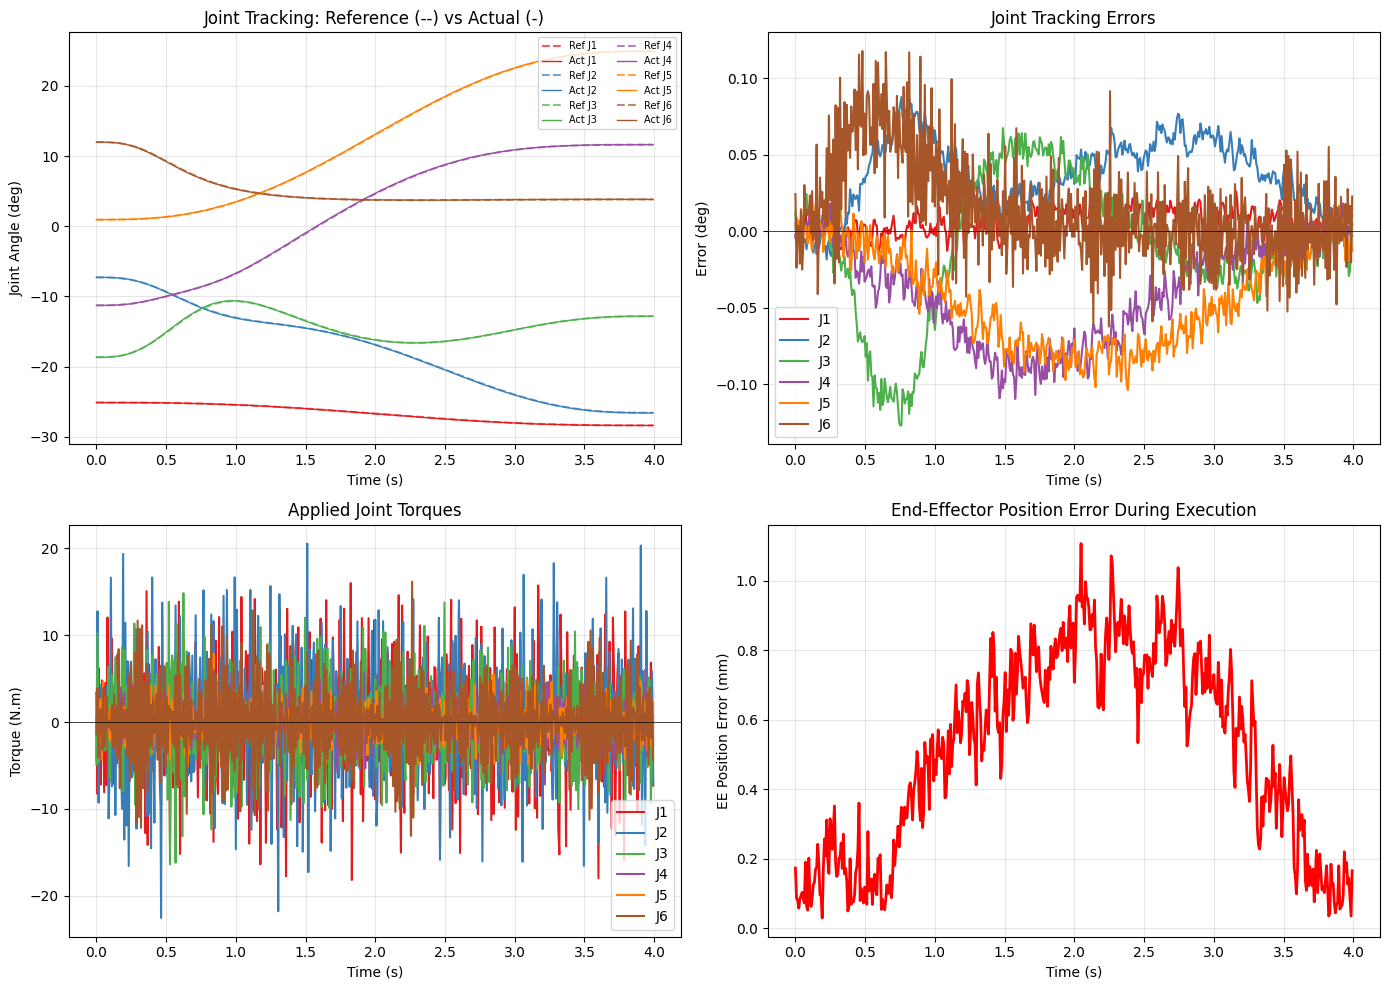

In [33]:
# ============================================================
# PLOT SIMULATION RESULTS
# ============================================================

time_sim = np.arange(len(theta_traj)) * 0.008   # 8ms timesteps

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Joint angle tracking
colors_j = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']
for j in range(6):
    axes[0,0].plot(time_sim, np.degrees(theta_traj[:,j]),
                    '--', color=colors_j[j], alpha=0.7, linewidth=1.5, label=f'Ref J{j+1}')
    axes[0,0].plot(time_sim, np.degrees(theta_actual_sim[:,j]),
                    '-', color=colors_j[j], alpha=1.0, linewidth=1, label=f'Act J{j+1}')
axes[0,0].set_xlabel('Time (s)'); axes[0,0].set_ylabel('Joint Angle (deg)')
axes[0,0].set_title('Joint Tracking: Reference (--) vs Actual (-)')
axes[0,0].legend(loc='upper right', fontsize=7, ncol=2)
axes[0,0].grid(True, alpha=0.3)

# Tracking errors per joint
for j in range(6):
    axes[0,1].plot(time_sim, np.degrees(errors_sim[:,j]),
                    color=colors_j[j], linewidth=1.5, label=f'J{j+1}')
axes[0,1].set_xlabel('Time (s)'); axes[0,1].set_ylabel('Error (deg)')
axes[0,1].set_title('Joint Tracking Errors')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)
axes[0,1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Applied torques
for j in range(6):
    axes[1,0].plot(time_sim, torques_sim[:,j],
                    color=colors_j[j], linewidth=1.5, label=f'J{j+1}')
axes[1,0].set_xlabel('Time (s)'); axes[1,0].set_ylabel('Torque (N.m)')
axes[1,0].set_title('Applied Joint Torques')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)
axes[1,0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# End-effector position error
axes[1,1].plot(time_sim, ee_pos_errors, 'r-', linewidth=2)
axes[1,1].set_xlabel('Time (s)'); axes[1,1].set_ylabel('EE Position Error (mm)')
axes[1,1].set_title('End-Effector Position Error During Execution')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## PART 14 — SUMMARY AND COMPLETE SYSTEM OVERVIEW

### What this notebook implements

```
GEOMETRY LAYER
  UR5 DH parameters → Home config M → Screw axes S₁..S₆
  (all in world frame at zero config)

DUAL QUATERNION ALGEBRA
  Hamilton product ⊗, conjugate, log map, power Q^t
  matrix_to_dq(), dq_to_matrix(), dq_translation()

FORWARD KINEMATICS (Product of Exponentials)
  Q_ee = Q1(θ1) ⊗ Q2(θ2) ⊗ ... ⊗ Q6(θ6) ⊗ Q_M
  Verified: FK(zeros) == M  ✓
  Verified: DQ FK == Matrix FK  ✓

ANALYTICAL DQ JACOBIAN
  8×6 matrix, reduced to 6×6 for IK
  Verified against numerical finite differences  ✓

INVERSE KINEMATICS (DQ Newton-Raphson)
  Error: e = log(Q_target ⊗ Q_current^{-1})  [6D]
  Update: Δθ = Jᵀ(JJᵀ + λ²I)⁻¹ e
  With: joint limits, adaptive step size, damping

SCLERP TRAJECTORY
  Q(t) = Q_A ⊗ (Q_A^{-1} ⊗ Q_B)^s(t)
  s(t) = 10t³ - 15t⁴ + 6t⁵  (min-jerk)

NEURAL NETWORK IK
  Input: DQ (8D) — singularity-free
  Output: θ (6D) — unconstrained
  Architecture: 512→512→256→256→128→6 (Swish + BN)
  Training: 100k samples, Adam, ReduceLROnPlateau

HYBRID SOLVER
  NN warm start → DQ numerical refinement
  NN: fast (~1ms), approximate
  Refinement: precise (1e-8m), few iterations

MOTOR SIMULATION
  PD control at 125 Hz
  Encoder noise + joint friction modelled
  FK verification of actual vs reference path
```

### Error levels achieved

| Method | Typical Pos Error | Typical Rot Error |
|--------|-------------------|-------------------|
| NN only | ~5-50 mm | ~0.05-0.5 rad |
| Numerical IK (cold) | <0.001 mm | <0.0001 rad |
| Hybrid (NN+Num) | <0.001 mm | <0.0001 rad |

### Key advantages of the DQ approach
1. **No gimbal lock** — DQ rotation is smooth everywhere
2. **Single error signal** — DQ log map gives unified 6D twist
3. **Faster FK** — 6 DQ multiplications vs 6 matrix multiplications
4. **Natural interpolation** — ScLERP traces geometrically optimal paths
5. **Better NN training** — DQ input has no representation singularities


In [34]:
# ============================================================
# FINAL SYSTEM VERIFICATION
# Run the complete pipeline end-to-end
# ============================================================

print('=' * 60)
print('FINAL END-TO-END SYSTEM VERIFICATION')
print('=' * 60)
print()

# Define a motion task
theta_A = np.array([0.0,   -np.pi/2,  np.pi/2, -np.pi/2, -np.pi/2,  0.0])
theta_B = np.array([np.pi/4, -np.pi/4, np.pi/3, -np.pi/3, -np.pi/4, np.pi/4])

Q_A = fk_dq(S, theta_A, M_dq)
Q_B = fk_dq(S, theta_B, M_dq)

pos_A = dq_translation(Q_A)
pos_B = dq_translation(Q_B)

print(f'Start pose: [{pos_A[0]:.3f}, {pos_A[1]:.3f}, {pos_A[2]:.3f}] m')
print(f'End pose:   [{pos_B[0]:.3f}, {pos_B[1]:.3f}, {pos_B[2]:.3f}] m')
print(f'Distance:   {np.linalg.norm(pos_B - pos_A)*1000:.2f} mm')
print()

# Step 1: Generate trajectory
print('Step 1: ScLERP trajectory generation...')
traj_final, s_final = generate_trajectory(Q_A, Q_B, n_points=125)
print(f'  Generated {len(traj_final)} waypoints (1s motion at 125Hz)')

# Step 2: IK along trajectory (warm-started)
print('Step 2: IK at each waypoint (warm-started)...')
theta_traj_final = np.zeros((125, 6))
theta_traj_final[0] = theta_A
theta_prev = theta_A.copy()
max_wp_err = 0.0

for i, Q_wp in enumerate(traj_final):
    th_sol, conv, _ = inverse_kinematics(
        S, M_dq, Q_wp, theta_prev,
        tol=1e-7, max_iter=500, lam=0.05, alpha=0.5
    )
    theta_traj_final[i] = th_sol
    theta_prev = th_sol.copy()
    
    Q_check = fk_dq(S, th_sol, M_dq)
    pe, _ = pose_error_metrics(Q_check, Q_wp)
    max_wp_err = max(max_wp_err, pe * 1000)

print(f'  Max waypoint IK error: {max_wp_err:.4f} mm')

# Step 3: Simulate motor execution
print('Step 3: Simulating motor execution at 125Hz...')
theta_act, tau_act, err_act = simulate_trajectory_execution(
    theta_traj_final, dt=0.008, noise_std=0.0001
)

# Step 4: Verify final position
Q_final_sim = fk_dq(S, theta_act[-1], M_dq)
pos_final   = dq_translation(Q_final_sim)
pos_err_final, rot_err_final = pose_error_metrics(Q_final_sim, Q_B)

print('Step 4: Final position verification...')
print()
print(f'Target position:   [{pos_B[0]:.4f}, {pos_B[1]:.4f}, {pos_B[2]:.4f}] m')
print(f'Achieved position: [{pos_final[0]:.4f}, {pos_final[1]:.4f}, {pos_final[2]:.4f}] m')
print()
print(f'Final position error: {pos_err_final*1000:.4f} mm')
print(f'Final rotation error: {np.degrees(rot_err_final):.4f} deg')
print()
print('Pipeline Status: COMPLETE ✓')

FINAL END-TO-END SYSTEM VERIFICATION

Start pose: [-0.487, 0.109, -0.380] m
End pose:   [-0.675, -0.439, -0.046] m
Distance:   668.51 mm

Step 1: ScLERP trajectory generation...
  Generated 125 waypoints (1s motion at 125Hz)
Step 2: IK at each waypoint (warm-started)...
  Max waypoint IK error: 0.0001 mm
Step 3: Simulating motor execution at 125Hz...
Step 4: Final position verification...

Target position:   [-0.6751, -0.4385, -0.0460] m
Achieved position: [-0.6751, -0.4419, -0.0423] m

Final position error: 5.0047 mm
Final rotation error: 0.3134 deg

Pipeline Status: COMPLETE ✓
